# Instalação, Importação e Tratamento dos Dados

In [ ]:
# Instalação de dependências (Descomente se for rodar no Google Colab pela primeira vez)
# !pip install pandas matplotlib seaborn numpy

import pandas as pd
import io
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
import matplotlib.patches as patches

# Configuração estética global para gráficos com qualidade de publicação
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'figure.dpi': 150})

# ==============================================================================
# 1. INSIRA SEUS DADOS AQUI
# ==============================================================================

texto_csv_triagem = """Autores (Ano),Título do Artigo,Duplicado,Base,Status,Filtro (Critério),Justificativa
Fernandes et al. (2026),"Blocks or Text: Who Struggles, Who Thrives?",TRUE,ACM,Incluído,Atende a todos os CIs,Avalia empiricamente o impacto de duas abordagens de linguagens educacionais (blocos e texto) na compreensão e tempo com mais de 350 crianças iniciantes.
Thorgeirsson et al. (2024),Recursion in Secondary Computer Science Education: A Comparative Study of Visual Programming Approaches,TRUE,ACM,Incluído,Atende a todos os CIs,Apresenta e avalia empiricamente uma nova linguagem de programação visual educacional (Algot) com estudantes iniciantes de 14 a 17 anos.
Dietz et al. (2023),Visual StoryCoder: A Multimodal Programming Environment for Children's Creation of Stories,TRUE,ACM,Incluído,Atende a todos os CIs,Propõe e avalia uma nova linguagem visual estruturada em blocos (Visual StoryCoder) desenhada especificamente para crianças de 5 a 8 anos.
Riahi et al. (2026),Exploring Teacher-Chatbot Interaction and Affect in Block-Based Programming,TRUE,ACM,Excluído,"CI3, CE5",Explora a interação de professores do ensino fundamental (falha em CI3) com chatbots (ferramenta de suporte - CE5) em ambiente de blocos.
Fiori et al. (2025),How Are We Teaching Programming to Students with Intellectual Disabilities? A Systematic Review of the Literature,TRUE,ACM,Excluído,CE3,"Consiste em uma revisão sistemática da literatura analisando 18 estudos empíricos, caracterizando-se como estudo secundário."
Deiner & Fraser (2024),NuzzleBug: Debugging Block-Based Programs in Scratch,TRUE,ACM,Excluído,CE5,"Apresenta o NuzzleBug, uma ferramenta de depuração para Scratch, focando em suporte sem alterar a linguagem ou sua sintaxe subjacente."
Li et al. (2026),RoboBlockly Studio: Conversational Block Programming with Embodied Robot Feedback for Computational Thinking,TRUE,ACM,Excluído,CE5,"Propõe um tutor conversacional (Chatbot) e feedback de robôs acoplado a uma linguagem existente, caracterizando-se como ferramenta de suporte."
Repenning & Basawapatna (2021),Smacking Screws with Hammers: Experiencing Affordances of Block-based Programming through the Hourglass Challenge,TRUE,ACM,Excluído,"CI3, CE4","Introduz um desafio pedagógico focado em professores em formação, falhando no público-alvo (CI3) e configurando foco puramente pedagógico (CE4)."
Bofferding et al. (2022),The effect of play and worked examples on first and third graders' creating and debugging of programming algorithms,FALSE,ACM,Excluído,CE4,"Foca em uma estratégia puramente pedagógica (análise de exemplos resolvidos) em um jogo em blocos existente, sem propor intervenção na linguagem."
Thorgeirsson & Su (2021),Algot: An Educational Programming Language with Human-Intuitive Visual Syntax,TRUE,IEEE,Incluído,Atende a todos os CIs,"Apresenta uma nova linguagem de programação visual fundamentada em síntese de programa e programação por demonstração. O foco do estudo é dar suporte a novatos no aprendizado de programação, trazendo evidências preliminares de sua eficácia."
Mafukidze et al. (2024),Development of a Modularized Undergraduate Data Science and Big Data Curricular Using No-Code Software Development Tools,TRUE,IEEE,Incluído,Atende a todos os CIs,O artigo avalia o impacto do uso de linguagens de programação visual na performance de estudantes. O público-alvo consiste em 50 alunos universitários sem especialização em ciência da computação e com habilidades limitadas de programação.
Laura-Ochoa & Bedregal-Alpaca (2021),Development of Computational Thinking Skills: An Experience With Undergraduate Students,FALSE,IEEE,Incluído,Atende a todos os CIs,"O estudo avalia ambientes de programação baseados em blocos (Scratch, Lightbot) em comparação ao uso de pseudocódigo. A pesquisa apresenta resultados empíricos obtidos com 85 estudantes universitários iniciantes do curso de contabilidade."
Takamatsu et al. (2025),Enhancing Algorithm Comprehension for Visually Impaired Individuals With LLM-Based Programming Code Segmentation,TRUE,IEEE,Incluído,Atende a todos os CIs,Propõe e avalia uma interface de programação em blocos adaptada e estruturada via modelos de linguagem grandes. A interface foca em auxiliar a compreensão de código por indivíduos com deficiência visual.
Repenning & Basawapatna (2024),RULER: Prebugging with Proxy-Based Programming,TRUE,IEEE,Incluído,Atende a todos os CIs,"Introduz a ferramenta computacional RULER.game, que propõe um paradigma chamado de programação baseada em proxy voltada para programadores novatos. O trabalho contém uma avaliação empírica de taxas de erro com melhorias estatisticamente significativas."
Versissimo et al. (2023),A Study on How to Classify Exercises in Introductory Programming Courses: A Moodle Plugin Contribution,TRUE,IEEE,Excluído,CE5,"Apresenta o PETA, um plugin para a plataforma Moodle que extrai dados da interação dos estudantes com os exercícios. É uma ferramenta periférica de análise de aprendizagem."
Kastner-Hauler et al. (2021),Adapting an OER Textbook for the Inverted Classroom Model — How To Flip the Classroom with BBC micro:bit Example Tasks,FALSE,IEEE,Excluído,CE4,"O estudo trata do redesign e adaptação de um livro didático para introduzir o modelo de sala de aula invertida, com foco totalmente curricular."
Berrocal Arévalo et al. (2026),Culturally Responsive-Sustaining Computer Science in Elementary Education Supported Through Coding With ScratchJr,TRUE,IEEE,Excluído,CE4,"O trabalho foca na aplicação de pedagogias voltadas para equidade e narrativas folclóricas, engajando jovens aprendizes por meio do ScratchJr. Não é proposta avaliação ou intervenção no design da linguagem."
Choi & Choi (2024),Exploring the Impact of Code.org's Block-Based Coding Curriculum on Student Motivation in K-12 Education,TRUE,IEEE,Excluído,CE4,"O artigo explora o impacto de um currículo já existente (Code.org) na motivação dos alunos por meio da pesquisa de materiais instrucionais, sem alteração de sintaxe."
Turchi (2024),FlowPilot: A Generative AI-Driven Visual Language for Computational Thinking Education,TRUE,IEEE,Excluído,CE2,"O documento é classificado como formato curto ou abstract estendido, contendo apenas 3 páginas totais (pp. 353-355)."
Choi et al. (2023),Motivating the New Generation: Using Flipped Classroom and ARCS Model to Enhance Block-Based Programming Education,TRUE,IEEE,Excluído,CE4,"Investiga exclusivamente os efeitos do aprendizado invertido e do modelo de motivação ARCS em alunos do ensino fundamental, consistindo em uma abordagem puramente pedagógica."
Deiner & Fraser (2024),Nuzzlebug: Debugging Block-based Programs in Scratch,TRUE,IEEE,Excluído,CE6,"O artigo apresenta o Nuzzlebug, um depurador onisciente e interrogativo para o ambiente Scratch. Trata-se de uma ferramenta de suporte para investigações de código sem alterar o design da linguagem."
Hsu et al. (2023),The Artificial Intelligence Learning Anxiety and Self-Efficacy of In-Service Teachers Taking AI Training Courses,TRUE,IEEE,Excluído,"CI3, CE4","O estudo explora fatores afetivos em professores ativos no ensino fundamental e médio em treinamento, não atingindo o critério do público-alvo iniciante."
Gerini et al. (2024),A 3D Visual Programming Language for Tangible Coding in Extended Reality,FALSE,SCOPUS,Incluído,Atende a todos os CIs,"O estudo propõe e avalia XRBlocks, uma nova linguagem visual estruturada em blocos desenhada especificamente para ensinar fundamentos de lógica em ambientes de Realidade Estendida (VR) para estudantes do ensino médio."
Takamatsu et al. (2024),Computer Programming Education System for Visually Impaired Individuals,FALSE,SCOPUS,Incluído,Atende a todos os CIs,Propõe uma alteração de interface e estruturação (navegação baseada em linhas de blocos) para ajudar iniciantes com deficiências visuais. (Nota: Versão de conferência do artigo da IEEE).
Fuhrmann et al. (2026),Designing MoDa: A new tool for science learning through data-based computational modeling,FALSE,SCOPUS,Incluído,Atende a todos os CIs,"Desenvolve e avalia o MoDa, uma nova linguagem estruturada em blocos de domínio específico elaborada do zero para guiar o letramento em modelagem computacional para jovens."
Jiménez et al. (2026),Evaluating user performance and perceptions in a block-based visual programming language for socially assistive robots,FALSE,SCOPUS,Incluído,Atende a todos os CIs,O estudo propõe e avalia experimentalmente uma nova Linguagem de Programação Visual em blocos arquitetada especialmente para facilitar que usuários inexperientes operem robôs de assistência social.
Rathor et al. (2025),FloBlocks: an affordable and extensible tool for tangible block programming in education,FALSE,SCOPUS,Incluído,Atende a todos os CIs,"O estudo propõe e apresenta o FloBlocks, uma nova linguagem visual estruturada em blocos de papel (tangíveis) atrelados à visão computacional focada no ensino de baixo custo e redução de carga cognitiva para iniciantes."
Khalid et al. (2024),InerSens: A Block-Based Programming Platform for Learning Sensor Data Analytics in Construction Engineering Programs,FALSE,SCOPUS,Incluído,Atende a todos os CIs,"O estudo propõe e avalia empiricamente InerSens, uma nova plataforma educacional baseada em blocos projetada para iniciantes (engenheiros sem experiência) manipularem análises de sensores, com métricas de redução de carga cognitiva."
Wang et al. (2026),Lowering novice programming barriers with Medialib: studies of its effectiveness and transferability,FALSE,SCOPUS,Incluído,Atende a todos os CIs,Apresenta a implementação adaptada e avaliação de uma biblioteca Python simplificada construída em prol de transpor a curva de aprendizagem abstrata em aulas inaugurais.
Repenning (2026),"Proxy-Based Programming: Making Programming More Accessible through Virtual, Physical, and Social Embodiment",FALSE,SCOPUS,Incluído,Atende a todos os CIs,"O estudo formaliza e afere um novo paradigma visual voltado a novatos (programação por proxy via RULER.game), mitigando as falhas das interfaces normais em bloco."
Pwanedo Amos et al. (2025),A Bibliometric Exposition and Review on Leveraging LLMs for Programming Education,FALSE,SCOPUS,Excluído,CE3,Revisão bibliométrica e estudo de tendências para mapeamento de termos focada integralmente em LLMs no ensino superior.
Alkaabi et al. (2026),A Collaborative Multiagent Framework for Enhancing Learning in Object-Oriented Programming,FALSE,SCOPUS,Excluído,CE5,Valida a utilização de sistemas amparados por Agentes de Inteligência Artificial para dar apoio teórico e estrutural aos alunos de programação.
Qing & Chen (2025),A Conceptual Framework for an LLM-Powered Multimodal Affective Tutoring System for Programming Education,FALSE,SCOPUS,Excluído,CE5,O artigo apresenta base teórica/arquitetural para criar um tutor automatizado capaz de reagir às emoções faciais do estudante.
Aimicheva et al. (2026),A Digital Ecosystem Model for Developing Logical Thinking in Novice Programmers: Integrating Visualization Technologies and GenAI,FALSE,SCOPUS,Excluído,"CE4, CE5",Foca em modelar processos cognitivos acoplando a espiral instrucional da Taxonomia de Bloom à infraestrutura dos assistentes de GenAI.
Xu et al. (2023),A Digital Game-based Learning Approach to Improve Students' Learning Performance of Senior High School Programming Courses,FALSE,SCOPUS,Excluído,CE4,Avalia o engajamento e a eficácia puramente de uma metodologia de aprendizagem baseada em jogos digitais em sala de aula.
Ocay & Rodrigo (2025),A Field Study on the Use of Gen AI to Support Computing Education,FALSE,SCOPUS,Excluído,CE5,Mapeia as consequências da integração experimental do uso do ChatGPT por estudantes calouros em suas tarefas universitárias.
Chen (2025),A Framework of Multilingual Conversion Errors: A Crosslinguistic Mediation Model in Teaching Chinese as a Second Language,FALSE,SCOPUS,Excluído,CE4,Estudo originário da linguística humana aplicada ao ensino do Mandarim como língua secundária; fora da Ciência da Computação.
Matsumoto et al. (2025),A GENERATIVE MODEL FOR NEXT-STEP CODE PREDICTION TOWARD PROACTIVE SUPPORT,FALSE,SCOPUS,Excluído,CE5,Propõe rede neural voltada ao rastreamento e predição autônoma do passo seguinte do aluno (ferramenta de Analytics).
Fang et al. (2026),A Human-AI Collaborative Strategy for Project-Based Learning Using Large Language Models,FALSE,SCOPUS,Excluído,"CE4, CE5",Integra Modelos LLMs colaborativos nas correntes metodológicas do Aprendizado Orientado a Projetos e da Educação Baseada em Resultados (OBE).
Ahmad et al. (2025),A Literature Review of Assessment Strategies for Enhancing Conceptual Understanding in Programming Education: Theoretical Perspectives and Empirical Evidence,FALSE,SCOPUS,Excluído,CE3,Estudo secundário consistente na sumarização bibliográfica e de métodos usados na educação computacional nos últimos dez anos.
Wong et al. (2025),A Mixed-Method Analysis on Student Acceptance and Learning Efficacy of Tangible Interfaces in Computational Thinking Education,FALSE,SCOPUS,Excluído,CE4,Avalia didaticamente ferramentas de blocos tangíveis (físicos) já existentes apoiadas num manual técnico e sessão de treinamento.
Alshalabi et al. (2025),A Mobile-Enabled Adaptive Gamification Framework for Programming Education,FALSE,SCOPUS,Excluído,CE4,Elabora princípios sistêmicos para que projetos contemplem narrativas ramificadas baseadas no engajamento por ludificação progressiva.
Mousavi et al. (2025),A Model-Driven Framework for Gamification of Learning Introductory Programming,FALSE,SCOPUS,Excluído,"CE4, CE5",Proposta arquitetural e conceitual guiada por modelos voltada à criação de interfaces de cursos gamificados e metodologias didáticas.
Barsukova et al. (2022),A New Educational Theory and Digital Technologies in Teaching at a University,FALSE,SCOPUS,Excluído,CE4,Documento focado em teoria da educação e uso de redes sociais/meios digitais de forma ampla no ensino superior.
Tseng et al. (2024),A Novel Approach to Boosting Programming Self-Efficacy: Issue-Based Teaching for Non-CS Undergraduates in Interdisciplinary Education,FALSE,SCOPUS,Excluído,CE4,Estudo pedagógico avaliando a eficácia da abordagem metodológica de ensino baseada em problemas (Issue-Based Teaching).
Wint & Funabiki (2021),A proposal of recommendation function for element fill-in-Blank problems in java programming learning assistant system,FALSE,SCOPUS,Excluído,CE5,Propõe uma funcionalidade de recomendação de exercícios para um sistema periférico assistente de aprendizado (JPLAS).
Papakostas et al. (2024),A Rule-Based Chatbot Offering Personalized Guidance in Computer Programming Education,FALSE,SCOPUS,Excluído,CE5,Estudo de construção de um Chatbot focado em dar orientações de código Java para os usuários.
Versissimo et al. (2023),A Study on How to Classify Exercises in Introductory Programming Courses: A Moodle Plugin Contribution,TRUE,SCOPUS,Excluído,CE6,Duplicata. Trata do desenvolvimento de um plugin (PETA) para o Moodle para análise de dados dos alunos.
Frankford et al. (2025),A Survey on Feedback Types in Automated Programming Assessment Systems,FALSE,SCOPUS,Excluído,CE5,Levantamento de eficácia pautando qual é o método de notificação de erros automatizados preferido pelos discentes num autograder.
Lei & Mendes (2021),A systematic literature review on knowledge tracing in learning programming,FALSE,SCOPUS,Excluído,CE3,Consiste em uma revisão sistemática da literatura sobre modelos de rastreamento de conhecimento do aluno.
Choi et al. (2023),A Systematic Literature Review on Performance Prediction in Learning Programming Using Educational Data Mining,FALSE,SCOPUS,Excluído,CE3,Consiste em uma revisão sistemática da literatura voltada para predição de desempenho via mineração de dados educacionais.
Meira et al. (2024),A Systematic Literature Review on the Use of Software Testing and Programming with Novice Students,FALSE,SCOPUS,Excluído,CE3,Estudo secundário (Revisão Sistemática da Literatura) referente à adoção de metodologias de teste com estudantes iniciantes.
Tonda Ramos et al. (2025),A Virtual Reality Application and an Interactive Board Game for Students Learning to Program,FALSE,SCOPUS,Excluído,CE4,"Analisa e atesta as validades metodológicas de três meios difusores de programação (VR, mídia tátil/física e manuais textuais)."
Veldthuis & Hermans (2024),A Word about Programming: Applying a Natural Language Vocabulary Acquisition Model to Programming Education,FALSE,SCOPUS,Excluído,CE4,Reporta o uso da apropriação curricular de modelos de linguagem natural (vocabulário) aplicados à pedagogia do ensino das lições de código.
Lin et al. (2025),Activity Diagrams as Cognitive Bridges: Revolutionizing Programming Education with AI,FALSE,SCOPUS,Excluído,CE5,Trata do desenvolvimento de aplicativo web autônomo acoplado no ChatGPT visando produzir e visualizar diagramas comportamentais unificados.
Kastner-Hauler et al. (2021),Adapting an OER Textbook for the Inverted Classroom Model - How to Flip the Classroom with BBC micro:bit Example Tasks,FALSE,SCOPUS,Excluído,CE4,Discute adaptação curricular e de livro didático para uso exclusivo da metodologia de sala de aula invertida.
T S & Thandeeswaran (2024),Adapting video-based programming instruction: An empirical study using a decision tree learning model,FALSE,SCOPUS,Excluído,CE5,Foca em sistemas E-Learning e analytics utilizando modelos preditivos de árvores de decisão para adaptar aulas focadas em mídia de vídeo.
Elhayany et al. (2024),Adaptive Learning at Scale: Investigating the Effects of Automated Formative Feedback in MOOC-based Data Science Learning,FALSE,SCOPUS,Excluído,CE5,Estuda a eficiência dos avaliadores automatizados de correção e envio de feedback instantâneo num curso em formato MOOC.
Lin et al. (2025),Adaptive learning with human factors and Artificial Intelligence: associations with training effectiveness in programming education,FALSE,SCOPUS,Excluído,CE5,Utiliza IA e ergonomia como ferramentas de analytics para ajustar e customizar dinamicamente a trilha do aprendiz num LMS.
Kwak et al. (2023),Adaptive programming language learning system based on generative AI,FALSE,SCOPUS,Excluído,CE5,Artigo propõe um framework conceitual focado em sistemas de tutoria inteligentes moldados por IA gerativa.
Ito et al. (2021),Advanced Comprehension Analysis Using Code Puzzle: Considering the Programming Thinking Ability,FALSE,SCOPUS,Excluído,CE5,"Foca em um método analítico para avaliar a compreensão via quebra-cabeças de código, caracterizando-se como ferramenta de avaliação/suporte."
Amburle et al. (2024),AI based Code Error Explainer using Gemini Model,FALSE,SCOPUS,Excluído,CE5,Discorre sobre uma ferramenta construída por cima da IA Gemini a fim de localizar e justifycar erros de código para o usuário.
Sharafudheen et al. (2025),AI-Driven Tutorial Code Learning System: Personalized Programming Education Through Adaptive Instruction and Gamification,FALSE,SCOPUS,Excluído,CE5,Demonstra os potenciais operacionais no pareamento de currículos com as recomendações de conteúdo via agentes artificiais.
Muda et al. (2025),Algorithmic Thinking in TVET Programming Education: An Analysis of Student Proficiency Levels and Implications,FALSE,SCOPUS,Excluído,CE4,"Coleta estatística baseada em enquetes para determinar a correlação psicométrica entre proficiências, desafios e níveis educacionais estudantis."
Thorgeirsson & Su (2021),Algot: An Educational Programming Language with Human-Intuitive Visual Syntax,TRUE,SCOPUS,Excluído,CE6,Propõe e traz resultados de avaliação empírica de uma nova linguagem visual (Algot) focada em iniciantes. (Nota: Duplicata exata do artigo já triado da base IEEE).
Shonhaji et al. (2025),An Educational App Builder Based on Atomic Design: Enhancing UI Development Learning for Beginner Students in Vocational Programming,FALSE,SCOPUS,Excluído,CE5,Introduz ferramenta/software focada no desenho e estruturação de hierarquia de componentes visuais (UI builder).
Fu et al. (2025),An Empirical Study of Adaptive Feedback to Enhance Cognitive Ability in Programming Learning among College Students...,FALSE,SCOPUS,Excluído,CE5,Aplica o rastreamento neurológico e dados de respostas rápidas para testar a entrega de feedback adaptativo provido aos universitários.
Yang et al. (2025),An Empirical Study of MBFL on Novice Programs Across Different Programming Languages,FALSE,SCOPUS,Excluído,CE5,Engenharia de Software teórica voltada ao crivo da técnica de localização de erros (MBFL) aplicada em algoritmos falhos gerados por calouros.
Umutlu (2022),An exploratory study of pre-service teachers’ computational thinking and programming skills,FALSE,SCOPUS,Excluído,CE4,"Estudo observacional focado em professores em formação usando ferramentas em blocos já existentes, sem intervenção tecnológica."
Orosoo et al. (2024),Analysing Code-Mixed Text in Programming Instruction Through Machine Learning for Feature Extraction,FALSE,SCOPUS,Excluído,CE5,Foca em infraestrutura computacional subjacente ao desenhar modelos ML para captar requisições em idiomas misturados em ambientes de ensino.
Kawasaki et al. (2023),Analysis of Exploratory Traces in Programming for Identifying Students Struggling in Construction of Program Logic,FALSE,SCOPUS,Excluído,CE5,Foca em análises e métodos (learning analytics) de rastros deixados pelos alunos no código para inferir dificuldades.
Wang (2025),Analysis of Online Learning Behavior in Java Programming Design Courses using a Hybrid Machine Learning Approach,FALSE,SCOPUS,Excluído,CE5,Trabalho restrito a classificar comportamentos por Machine Learning (Learning Analytics) a partir de logs em LMS.
Teixeira & Brito-Costa (2025),Analyzing Cognitive Effort in Python Programming: Eye-Tracking Insights on for Loops and Nested Loop Complexity,FALSE,SCOPUS,Excluído,CE5,Mensuração puramente analítica feita por mapeadores de rastreamento ocular a fim de relatar carga estressora ao se ler código Python clássico.
Chuang & Chang (2024),Analyzing novice and competent programmers' problem-solving behaviors using an automated evaluation system,FALSE,SCOPUS,Excluído,CE5,Foca em mineração de dados via sistema de avaliador automático para mapeamento comparativo do perfil de resolução de novatos e experientes.
Hristov et al. (2026),Applying Cognitive Load Theory to Teaching Programming in Elementary Education,FALSE,SCOPUS,Excluído,CE4,Apresentação e sistematização voltada para elencar o design instrucional amparado pela literatura em prol de superar sobrecarga de conteúdo.
Cheng et al. (2023),Applying Computational Thinking and Formative Assessment to Enhance the Learning Performance of Students in Virtual Programming Language,FALSE,SCOPUS,Excluído,CE5,Avalia a eficácia de um sistema visual focado unicamente na avaliação formativa dos estudantes (VPFAS).
Rajendran & Ramasamy (2024),Artificial Intelligence Integration in Programming Education: Implications for Pedagogy and Practice,FALSE,SCOPUS,Excluído,CE3,Trabalho de revisão abordando os paradigmas educacionais atuais mediante as Inteligências Artificiais e NLP.
Mergianian et al. (2026),Assessing Computational Thinking Using Log Data: A Scoping Review,FALSE,SCOPUS,Excluído,CE3,Estudo secundário (Revisão de Escopo) mapeando como os pesquisadores avaliam pensamento computacional utilizando dados de log.
Mia et al. (2025),Attention-Driven Clustering of Programming Problem Difficulty Using Statistical and Machine Learning Techniques,FALSE,SCOPUS,Excluído,CE5,Pesquisa voltada a ranquear a dificuldade em bancos de exercícios provenientes de plataformas de Juízes Online.
Sun et al. (2024),"Block-based versus text-based programming: a comparison of learners’ programming behaviors, computational thinking skills and attitudes toward programming",FALSE,SCOPUS,Excluído,CE4,Estudo pedagógico/comportamental que compara as modalidades preexistentes de blocos contra texto sem criar ou alterar uma linguagem.
Qi et al. (2024),Block-based versus Text-based Programming: A Comparison of Learners’ Programming Behaviors...,FALSE,SCOPUS,Excluído,CE4,Documento correlato e simplificado abordando e reportando resultados dos padrões estatísticos de uso de blocos contra ferramentas de texto.
Fernandes et al. (2026),"Blocks or Text: Who Struggles, Who Thrives?",TRUE,SCOPUS,Excluído,CE6,Duplicata exata do primeiro arquivo da ACM. O artigo valida as interações e tempo gasto comparativamente no escopo entre sintaxes visuais em blocos vs textuais.
Goenka & Thakkar (2026),BOOP: Write Right Code,FALSE,SCOPUS,Excluído,"CE4, CE5",Mapeamento metodológico estrito com framework (BOOP) imposto através de extensão para guiar mentalmente estudantes na confecção de scripts em OCaml.
Feng et al. (2026),Bot or Prof: Comparing the Characteristics of AI-generated and Instructor-written Responses to Student Queries in an Introductory Programming Course Forum,FALSE,SCOPUS,Excluído,CE5,Estudo puramente focado em comparar a qualidade do suporte a fóruns prestado por robôs conversacionais LLM em contraste com docentes.
Athukorala & De Silva (2025),Bridging Language Barriers in Programming Education: Java Programming Assistance Tool for Sinhala Native Speakers,FALSE,SCOPUS,Excluído,CE5,Estudo avaliativo sobre assistente de NLP voltado à conversão direta de textos no idioma falado em códigos em linguagem nativa Java.
Lei et al. (2025),Bridging Syntax and Problem Solving: Educators' Perspectives on Pattern-oriented Intelligent Programming Tutor,FALSE,SCOPUS,Excluído,CE5,Elaboração de Sistema de Tutoria Inteligente (ITS) arquitetado para gerar feedback durante os exercícios de programação.
Stein et al. (2023),Browser-based simulation for novice-friendly classroom robotics,FALSE,SCOPUS,Excluído,CE5,Apresenta plataforma de robótica virtual simulada em rede com ambiente de programação. Ferramenta de suporte ao currículo de robótica.
Gomes et al. (2025),ChatGPT as a Teaching Assistant in a CS1 course: An Experience Report,FALSE,SCOPUS,Excluído,CE5,Reportagem acadêmica traçando paralelo empírico entre os níveis de assistência dadas aos alunos pelo ChatGPT versus Monitores discentes (humanos).
Berrezueta-Guzman et al. (2024),Code Collaborate: Dissecting Team Dynamics in First-Semester Programming Students,FALSE,SCOPUS,Excluído,CE4,"Estudo focado exclusivamente em métricas comportamentais (colaboração, trabalho em equipe) via análise de versão."
Rebollido & Caro (2024),Code Comprehension Problems in Introductory Programming to Overcome ChatGPT,FALSE,SCOPUS,Excluído,CE4,Propõe uma tipologia de exercícios focada em leitura de código e raciocínio a fim de inibir o plágio via ChatGPT.
Maeda et al. (2025),Code Sharing Platform for Better Code Writing Through Visual Programming and Trial and Error,FALSE,SCOPUS,Excluído,CE5,Aprimora um sistema de compartilhamento de código de texto anexando opções em blocos para reduzir carga cognitiva na plataforma.
Ez-Zaouia & Boumarafi (2025),Codigen: Enhancing Personalized Programming Education with Visual Authoring and LLMs,FALSE,SCOPUS,Excluído,CE5,Codigen consiste numa ferramenta autoral para docentes criarem insumos baseados nos modelos de IA estruturados em prompts.
Nutalapati et al. (2024),Coding Buddy: An Adaptive AI-Powered Platform for Personalized Learning,FALSE,SCOPUS,Excluído,CE5,"Trata-se do Coding Buddy, um sistema de tutoria on-line inteligente que analisa e responde aos erros dos estudantes ativamente."
Singh & Rajendran (2024),Cognitive engagement as a predictor of learning gain in Python programming,FALSE,SCOPUS,Excluído,CE5,Utiliza técnicas de Learning Analytics para modelar a correlação estatística entre foco cognitivo e performance em Python.
Tan et al. (2024),Collaborative dialogue patterns of pair programming and their impact on programming self-efficacy and coding performance,FALSE,SCOPUS,Excluído,CE4,Avalia estritamente interações comunicativas mediante uso da didática de pair programming sem interferência no sistema em uso.
Kastner-Hauler et al. (2022),Combined Effects of Block-Based Programming and Physical Computing on Primary Students' Computational Thinking Skills,FALSE,SCOPUS,Excluído,CE4,Avaliação pedagógica focada no uso da computação física instrucional via kits micro:bit conjugada a um livro de recursos educacionais abertos.
Mohammed et al. (2026),Combining Computational Thinking Concepts and Machine Learning Techniques for Early Prediction of Digital Humanities Students' Programming Performance,FALSE,SCOPUS,Excluído,CE5,Coleta indicativos estudantis oriundos das Humanidades Digitais treinando as redes LSTM em detectar desistências iminentes.
Sun et al. (2021),"Comparing learners’ knowledge, behaviors, and attitudes between two instructional modes of computer programming in secondary education",FALSE,SCOPUS,Excluído,CE4,Compara as estratégias pedagógicas de programação desplugada versus aulas expositivas centradas no instrutor.
Galbá N-Ojer et al. (2025),Computational Thinking and Artificial Intelligence Training Program for Students with Intellectual Disability: A Path to Inclusion,FALSE,SCOPUS,Excluído,CE4,Pesquisa qualitativa focada no impacto metodológico e inclusivo de um treinamento usando blocos e IA para alunos com deficiência intelectual.
Noordin (2025),Computational Thinking Through Scaffolded Game Development Activities: A Study with Graphical Programming,FALSE,SCOPUS,Excluído,CE4,Usa a plataforma mBlock sem alterações atrelada apenas a técnicas pedagógicas de suporte (scaffolding) na criação de jogos.
Cafarella & Vasconcelos (2025),Computational thinking with game design: An action research study with middle school students,FALSE,SCOPUS,Excluído,CE4,Pesquisa focada nos resultados instrucionais da aplicação do currículo da plataforma Code.org.
Smit & du Plessis (2024),Cracking the Code: Understanding Source Code Plagiarism to Enable Learning,FALSE,SCOPUS,Excluído,CE5,"Trabalho fundamentado em metodologias e políticas para contornar, detectar (MOSS) e lidar eticamente com o plágio usando IA na educação de TI."
Chang et al. (2026),Cultivating thinking skills and computational thinking in higher education: A case-based decision-support model from Taiwan,FALSE,SCOPUS,Excluído,CE4,Pesquisa voltada à criação teórica de modelos matemáticos e critérios de avaliação de competências do pensamento computacional baseados em decisão.
Berrocal Arevalo et al. (2026),Culturally Responsive-Sustaining Computer Science in Elementary Education Supported Through Coding with ScratchJr,TRUE,SCOPUS,Excluído,CE6,Duplicata. Estudo curricular aplicando as metodologias de ensino inclusivo de minorias através de atividades folclóricas no aplicativo ScratchJr.
Yang et al. (2023),Data-driven Analysis of Elementary School Students' Computational Thinking through Scratch Projects,FALSE,SCOPUS,Excluído,"CE2, CE5",Relato de progresso (work-in-progress) de 4 páginas que analisa dados do Scratch existentes.
Wang & Dasgupta (2022),"Dataland: An Informed, Situated, and Critical Approach to Data Literacy",FALSE,SCOPUS,Excluído,"CE2, CI4","Apresenta um sistema (Dataland) ainda em desenvolvimento (demo de 4 páginas), falhando em apresentar resultados empíricos consolidados."
Ma et al. (2025),DBox: Scaffolding Algorithmic Programming Learning through Learner-LLM Co-Decomposition,FALSE,SCOPUS,Excluído,CE5,A ferramenta investigada (Decomposition Box) presta amparo para facilitar como o aprendiz quebra e estrutura hierarquicamente os seus algoritmos.
Kong (2026),Deductive and Progressive Programming and Teaching A Technical Deep Dive for Assembly Language Pedagogy,FALSE,SCOPUS,Excluído,CE4,Abordagem teórica de sala de aula introduzindo métodos regressivos dedicados a facilitar os fluxos mentais subjacentes à programação Assembly.
Sparf et al. (2022),Design for learning programming Approaches taken by novice learners,FALSE,SCOPUS,Excluído,CE4,"Mapeia comportamentalmente cinco abordagens (matemática, tentativa e erro) que novatos usam ao programar."
Agbo et al. (2023),"Design, development, and evaluation of a virtual reality game-based application to support computational thinking",FALSE,SCOPUS,Excluído,"CE4, CE5",O estudo propõe e avalia um aplicativo de realidade virtual no formato de minijogo para apoiar o pensamento computacional.
Hu et al. (2025),Designing a Large Language Model Agent to Support Programming Problem Solving Based on Self-Regulated Learning,FALSE,SCOPUS,Excluído,CE5,Sistema que propõe guiar e modelar o aluno (CodeBuddy) pelas estapas de aprendizagem através de IA tutelar contínua.
Dahshan & Galanti (2023),Designing Integrated Math + CT Activities to Promote Sensemaking about Place Value in Grades K-2,FALSE,SCOPUS,Excluído,"CE2, CE4","Foco no design instrucional/pedagógico desenvolvido por professores em treinamento, submetido em formato curto (SIGCSE)."
Simarmata et al. (2024),Determinant factors of distance self-learning performance on computer programming language education - a concept map approach,FALSE,SCOPUS,Excluído,CE4,Estudo de mapeamento conceitual propondo nove fatores didáticos e tecnológicos determinantes para o ensino remoto de programação.
Gupta et al. (2025),Development and Validation of Adaptable Rubrics for Programming Assessments: Measuring Computational Competencies,FALSE,SCOPUS,Excluído,CE4,Trabalho direcionado para a criação e teste psicométrico de instrumentos de avaliação (rubricas textuais) direcionadas à nota.
Mafukidze et al. (2024),Development of a Modularized Undergraduate Data Science and Big Data Curricular Using No-Code Software Development Tools,TRUE,SCOPUS,Excluído,CE6,Duplicata. Avalia impacto de ferramentas no-code e linguagens visuais em estudantes não-técnicos.
Shigematsu & Matsumoto (2022),Development of Learning Support System with Problem Posing of Fill-in-the-Blank Questions,FALSE,SCOPUS,Excluído,CE5,"Foca num sistema de apoio para geração de exercícios de preenchimento de lacunas, sem propor alteração sintática/linguagem."
Büscher (2025),Differences in Students’ Computational Thinking Activities when Designing an Algorithm for Drawing Plane Figures,FALSE,SCOPUS,Excluído,CE4,Observação cognitiva detalhada sobre como alunos estruturam pensamento em interfaces de blocos não alteradas no artigo.
Choi & Choi (2024),Discovering Programming Talent and Improving Learning Motivation with CodeCombat in K-12 Education,FALSE,SCOPUS,Excluído,CE4,Pesquisa voltada ao rastreamento e descoberta de crianças com alta propensão educacional via uso do CodeCombat.
Evans & Cleghorn (2022),Do student teachers see what learners see? – Avoiding instructional dissonance when designing worksheets,FALSE,SCOPUS,Excluído,CE4,"Completamente fora de escopo, analisa folhas de exercícios para literacia e matemática infantil."
Jin et al. (2024),DVRT: Design and evaluation of a virtual reality drone programming teaching system,FALSE,SCOPUS,Excluído,CE5,"Desenvolve um simulador/ambiente em Realidade Virtual de ensino para operação de drones, atuando como plataforma suporte curricular."
Liu et al. (2026),"Effect of generative AI-based conceptual and metacognitive scaffolding on elementary students’ computational thinking, academic achievement, and programming self-efficacy",FALSE,SCOPUS,Excluído,CE5,Aplica prompts via GenAI com o escopo de agir como andaime metacognitivo nas resoluções dos exercícios em turma escolar.
Inoue et al. (2022),Effect of impression on learners during partnered robots learning programming while playing board games against each other,FALSE,SCOPUS,Excluído,CE4,"Investiga motivação através de robôs em jogos de tabuleiro, sem propor/avaliar o design de uma linguagem educacional."
Yende (2023),Effectiveness of music education in developing and fostering reading and writing for learners,FALSE,SCOPUS,Excluído,CE4,"Apenas relacionado a educação básica com ensino de leitura e escrita através da educação musical, fora da computação."
Cheung et al. (2025),Effectiveness of Online Higher Education Programming Education During COVID-19 Under the Lens on the 5E Instructional Model,FALSE,SCOPUS,Excluído,CE4,"Levantamento (survey) analisando a eficácia do ensino EAD de linguagens consolidadas (Java, C++) via videoconferência."
Cheng & Chen (2026),Effectiveness of Pre-Test and Post-Test Strategies in Programming Education: A Five-Year Longitudinal Study,FALSE,SCOPUS,Excluído,CE4,Estudo observacional focado na transição sistemática de métricas pedagógicas aplicando o preceito de Pré/Pós teste de validação.
Yu et al. (2025),Effects of Block-Based Visual Programming on K-12 Students’ Learning Outcomes,FALSE,SCOPUS,Excluído,CE3,Extrai e aglutina os tamanhos de efeito de trabalhos experimentais alheios configurando assim uma meta-análise estatística secundária.
Zhong et al. (2022),Effects of programming tools with different degrees of embodiment on learning Boolean operations,FALSE,SCOPUS,Excluído,CE4,"Compara os efeitos instrucionais de kits de hardware físico com graus de corporeidade diferentes, focando em mídia instrucional, não design de sintaxe."
Jimenez et al. (2026),Effects of Robots Using Board Games to Promote Computational Thinking in Humanities Students,FALSE,SCOPUS,Excluído,CE4,Usa o lúdico via interação do aluno com robôs que atuam como pares didáticos simulando oponentes ou companheiros em jogos de tabuleiro.
Piedade & Dorotea (2023),Effects of Scratch-Based Activities on 4th-Grade Students’ Computational Thinking Skills,FALSE,SCOPUS,Excluído,CE4,"Avalia o impacto metodológico de atividades usando o Scratch existente, sem propor inovações no design sintático ou da linguagem."
Herlambang (2025),Efficacy of Blended Learner-Centric Approaches in Computer Programming Education,FALSE,SCOPUS,Excluído,CE4,Foco curricular mensurando a eficácia de didáticas do Ensino Híbrido (Blended Learning) contra educação clássica.
Park & Oh (2023),EliRank: A Code Editing History Based Ranking Model for Early Detection of Students in Need,FALSE,SCOPUS,Excluído,CE5,Propõe modelo (EliRank) com base no histórico de edições do código dos usuários a fim de notificar e guiar as interações de tutoria inteligente.
Gepner et al. (2023),Empirical Studies of Students Behaviour Using Scottie-Go Block Tools to Develop Problem-Solving Experience,FALSE,SCOPUS,Excluído,CE4,Estudo observacional focado puramente em avaliar comportamentos mediante o uso de um método didático baseado em jogo de tabuleiro e Scratch.
Chan et al. (2025),Empowering Engagement with Learning Analytics-Based Feedback for Programming Education,FALSE,SCOPUS,Excluído,CE5,Instrumentaliza e correlaciona a aplicação de feedback oriundo de sistemas Analytics focado na autorregulação de alunos.
Lin et al. (2025),Empowering Students with Varying Self-Efficacy by Intelligent Hints to Enhance Programming Education,FALSE,SCOPUS,Excluído,CE5,Propõe a implementação e avaliação de um sistema capaz de gerar dicas visuais automatizadas como suporte guiado ao estudante.
Kátai et al. (2024),Enacting algorithms: Evolution of the algorythmics storytelling,FALSE,SCOPUS,Excluído,CE4,"Promove o ensino de metodologias e estruturas via visualização cênica, filmes curtos e estratégias pedagógicas narrativas."
Pimpimool (2024),Enhancing Algorithm and Programming Education through Collaborative Blended Learning: A Problem-Based Approach for First-Year Students,FALSE,SCOPUS,Excluído,CE4,Documento avaliativo sobre aprendizado híbrido (Blended Learning) colaborativo para os alunos do primeiro ano universitário.
Takamatsu et al. (2025),Enhancing Algorithm Comprehension for Visually Impaired Individuals With LLM-Based Programming Code Segmentation,TRUE,SCOPUS,Excluído,CE6,Duplicata. Propõe a criação e avaliação de uma nova interface/sintaxe em blocos focada em deficientes visuais via segmentação de modelos de linguagem.
Guiza (2026),Enhancing Algorithmic Design through Mobile-Supported Constructivist Learning: A Problem-Based Approach,FALSE,SCOPUS,Excluído,CE4,Desenvolvimento e mensuração instrucional embasado nas premissas das matrizes educacionais construtivistas e orientadas por problemas.
Matobobo et al. (2025),Enhancing Computational Thinking and Problemsolving in Programming Education Through Generative AI: A Scoped Review,FALSE,SCOPUS,Excluído,CE3,Pesquisa exploratória descritiva estruturada em forma de revisão de escopo a fim de levantar os impactos e papéis éticos do uso de IAs geradoras.
Sarshartehrani et al. (2024),Enhancing E-Learning Experience Through Embodied AI Tutors in Immersive Virtual Environments...,FALSE,SCOPUS,Excluído,CE5,Estudo sobre integração de tutores inteligentes baseados em IA dentro da Realidade Virtual; não incide no design da linguagem.
Sibia (2024),Enhancing Novice Programmers? Understanding through Interactive Visualizations and Multiple Representations,FALSE,SCOPUS,Excluído,"CE2, CI4","Proposta acadêmica inserida num Consórcio Doutoral que discute as pesquisas vindouras da autora, sem resultados empíricos da intervenção."
Calderón & Vargas (2025),Enhancing Object-Oriented Programming Education through Virtual Learning and Adaptive AI Technologies,FALSE,SCOPUS,Excluído,CE5,Análise não-supervisionada projetada para categorizar métricas comportamentais visando adaptar conteúdo na plataforma de ensino.
Chen & Huang (2024),Enhancing programming learning performance through a Jigsaw collaborative learning method in a metaverse virtual space,FALSE,SCOPUS,Excluído,CE4,Implementa método colaborativo ('Jigsaw') no metaverso atrelado às tarefas no Scratch sem criar linguagem ou sintaxe nova.
Yang et al. (2024),Enhancing python learning with PyTutor: Efficacy of a ChatGPT-Based intelligent tutoring system in programming education,FALSE,SCOPUS,Excluído,CE5,"Avalia o PyTutor, uma ferramenta de Inteligência Artificial elaborada como tutor de dicas instantâneas e soluções em Python."
Mladenović et al. (2026),Enhancing universal access to programming education: paradigm‑aligned transition from block‑based to text‑based languages,FALSE,SCOPUS,Excluído,CE4,O estudo afere empiricamente a vantagem pedagógica da transição curricular iniciada através de blocos (MakeCode) antecedendo texto (Python).
Dunifa (2023),Evaluating Oral English Program for Non-English Major Students: Focusing on Self-Assessment of Students’ Speaking Abilities and Their Needs,FALSE,SCOPUS,Excluído,CE4,Estudo referente a letramento oral de língua estrangeira sem vínculo com aprendizagem de ciência da computação.
Sawalha et al. (2025),Evaluating the Effectiveness of Voice and Text Software Chatbots on Students' Programming Skills,FALSE,SCOPUS,Excluído,CE5,Teste de experiência do usuário comparando os impactos comportamentais de interações textuais contra comunicações orais com Chatbots.
Noordin & Karunanithi (2026),Evaluating the impact of game development-based learning on programming skill acquisition and student engagement,FALSE,SCOPUS,Excluído,CE4,Pesquisa voltada à avaliação metodológica na didática de design de jogos operando e ensinando por meio do lúdico.
Chen et al. (2025),Examining the Usage of Generative AI Models in Student Learning Activities for Software Programming,FALSE,SCOPUS,Excluído,CE5,Analisa e reporta comportamentos discentes no uso de IAs gerativas como facilitador para responder questões.
Su et al. (2025),Exploring gender and educational background effects on 21st-century competencies in robot-integrated STEM education...,FALSE,SCOPUS,Excluído,CE4,Avaliação comportamental que afere características demográficas e satisfação num currículo interdisciplinar robótico.
Liu et al. (2023),Exploring Machine Learning Methods to Identify Patterns in Students' Solutions to Programming Assignments,FALSE,SCOPUS,Excluído,CE5,Descreve ferramenta de suporte usando Machine Learning para automatizar classificação de padrões e dar feedback de código.
Fenu et al. (2024),Exploring Student Interactions with AI in Programming Training,FALSE,SCOPUS,Excluído,CE5,Descreve metodologicamente o comportamento e os padrões de requisição dos aprendizes nas IAs conversacionais (ChatGPT) durante as atividades em C.
Ma et al. (2024),EXPLORING STUDENT PERCEPTION AND INTERACTION USING CHATGPT IN PROGRAMMING EDUCATION,FALSE,SCOPUS,Excluído,CE5,Analisa dados de diálogo e percepção de aprendizes com o uso do ChatGPT no aprendizado de Python.
Riahi et al. (2026),Exploring Teacher-Chatbot Interaction and Affect in Block-Based Programming,TRUE,SCOPUS,Excluído,CE6,Duplicata. Pesquisa as interações de educadores (público docente) mediadas por chatbots operando via plataformas de blocos.
Wu et al. (2024),Exploring the Effects of Automated Feedback on Students in Introductory Programming Using Self-regulated Learning Theory,FALSE,SCOPUS,Excluído,CE5,Estudo das implicações de utilizar ferramentas de feedback/sistemas de avaliação automática baseados na teoria de aprendizado autorregulado.
Choi & Choi (2024),Exploring the Impact of Code.org's Block-Based Coding Curriculum on Student Motivation in K-12 Education,TRUE,SCOPUS,Excluído,CE6,Duplicata exata da base IEEE. Investiga o impacto de currículo preexistente usando modelo motivacional.
Hsueh et al. (2022),EXPLORING THE INFLUENCE OF STUDENTS’ MODES OF BEHAVIORAL ENGAGEMENT IN AN ONLINE PROGRAMMING COURSE...,FALSE,SCOPUS,Excluído,"CE4, CE5",Análise preditiva (Learning Analytics) focada em engajamento estudantil via log de vídeos/plataforma em cursos de Python online.
Zhuang et al. (2025),Exploring the Integration of Artificial Intelligence and Programming Education: A Practice-Oriented Study on the Development of Computational Thinking Based on Human-AI Co-Creation,FALSE,SCOPUS,Excluído,CE4,Ensaia um escopo projetual estruturado para que humanos atuem formatando aulas em conjunto com agentes computacionais.
Turchi (2024),FlowPilot: A Generative AI-Driven Visual Language for Computational Thinking Education,TRUE,SCOPUS,Excluído,CE6,"Duplicata rejeitada. Documento com 3 páginas totais, qualificado como short paper."
Versino et al. (2025),Fostering Novice Collaboration in ML-Based System Design Through Visual Languages and Touch Interfaces,FALSE,SCOPUS,Excluído,CI3,Extensão visual tátil elaborada com as ressalvas e prioridades para treinamento de peritos de domínio específicos em invés de público básico (novatos genéricos).
Lonati & Morpurgo (2021),Fostering Strategic Knowledge and Program Comprehension Skills in Students Struggling with CS1,FALSE,SCOPUS,Excluído,"CE2, CE4",Documento excessivamente curto (1 página de anais) visando buscar feedback sobre novos materiais instrucionais pedagógicos.
Lathigara et al. (2026),From Passive to Participatory by Leveraging Artificial Intelligence for Active Learning Environments,FALSE,SCOPUS,Excluído,"CE4, CE5",Trabalha princípios metodológicos de engajamento ativo através da integração de questionários responsivos em aulas interativas (pair programming).
James et al. (2025),From Typing to Insights: An Interactive Code Visualization and Error Detection for Enhanced Student Support Using Keystroke Data,FALSE,SCOPUS,Excluído,CE5,Plataforma de mapeamento comportamental guiada pelos logs das digitações a fim de construir análises das execuções em turmas introdutórias.
Sirikong & Visutsak (2024),Gamifying Python: Enhancing Learning Outcomes and Motivation through a Game-Based Approach,FALSE,SCOPUS,Excluído,CE4,"Projeta e aplica uma casca de gamificação em aulas expositivas de Python tradicional, avaliando níveis de aprendizado prático e motivação do grupo."
Chen & Liu (2026),Gen-PBL in Vocational Big Data Education: Exploring Cognitive Offloading Behaviors via Structured GenAI Scaffolding,FALSE,SCOPUS,Excluído,"CE4, CE5",Exploração comportamental de alunos interagindo com tutores/assistentes geradores de código via Inteligência Artificial.
Niousha et al. (2023),Gender Characteristics and Computational Thinking in Scratch,FALSE,SCOPUS,Excluído,"CE2, CE4",Resumo curto derivado de conferência (SIGCSE) focado na análise de gênero em projetos do Scratch.
Nitchot & Gilbert (2026),Generative AI and Knowledge Mapping in Programming Education: Student Learning and Engagement,FALSE,SCOPUS,Excluído,CE5,Verifica a complementaridade entre o uso associativo de mapas de conhecimentos visuais pareados à elucidação rápida via IAs LLM.
Sadat Shanto et al. (2025),Generative AI for Programming Education: Can ChatGPT Facilitate the Acquisition of Fundamental Programming Skills for Novices?,FALSE,SCOPUS,Excluído,CE5,Verifica a proficiência em explicar conceitos e conduzir ensino agindo de forma independente via IA conversacional ChatGPT.
Hashmi et al. (2024),Generative AI's impact on programming students: frustration and confidence across learning styles,FALSE,SCOPUS,Excluído,CE5,Análise psicométrica pautada por avaliar como a adesão aos assistentes de IA Generativa impactam os estados emocionais dos aprendizes.
Li et al. (2025),Generative Artificial Intelligence Supported Programming Learning: Learning Effectiveness and Core Competence,FALSE,SCOPUS,Excluído,CE5,Mensura em escola profissionalizante o ganho de aptidões oriundo de turmas suportadas pelos LLMs geradores de texto.
Chen et al. (2025),Generative Feedback for Code Learning: A Study on LLM-Driven Formative Assessment,FALSE,SCOPUS,Excluído,CE5,Trabalho restrito à integração de LLMs para a automação de feedbacks formativos sem intervir ou propor design de linguagem.
Prather et al. (2022),Getting By With Help From My Friends: Group Study in Introductory Programming Understood as Socially Shared Regulation,FALSE,SCOPUS,Excluído,CE4,Investiga teorias de auto e co-regulação (aspectos psicológicos) em atividades de programação realizadas em grupo.
Raikwar et al. (2025),Goos-Gambit: An Educational Card Game,FALSE,SCOPUS,Excluído,CE4,Pesquisa voltada à computação desplugada através da criação de um jogo de cartas (Goos-Gambit) lúdico e interativo.
Fiori et al. (2025),How Are We Teaching Programming to Students with Intellectual Disabilities? A Systematic Review of the Literature,TRUE,SCOPUS,Excluído,CE6,Duplicata. Consiste em uma revisão sistemática compilando pesquisas atreladas a inclusão e deficiência intelectual.
Tsai et al. (2025),How block-based programming supports novice learners’ coding comprehension: Evidence from eye-tracking lag-sequential analysis,FALSE,SCOPUS,Excluído,CE4,Analisa dados de rastreamento ocular comparativos em sujeitos operando o Scratch versus Python clássico não-modificado.
Wang et al. (2023),How problem difficulty and order influence programming education outcomes in online judge systems,FALSE,SCOPUS,Excluído,CE5,Explora estatisticamente os impactos da dificuldade de atividades nos Sistemas de Juízes Online (OJ).
Zouhair & Nafidi (2025),IMPACT OF SCRATCH PROGRAMMING ON GEOMETRY SKILL DEVELOPMENT IN PRIMARY EDUCATION,FALSE,SCOPUS,Excluído,CE4,Mapeia as melhorias nas disciplinas curriculares tradicionais matemáticas impulsionadas secundariamente pelo contato com a plataforma Scratch.
Syaifudin et al. (2025),Implementing Data Integration Self-Study: A Curriculum Development for Android Programming Learning Assistance System,FALSE,SCOPUS,Excluído,"CE4, CE5",Projeta material didático atrelado e customizado para operar com autoavaliação guiada em sistemas de tutorial e acompanhamento acadêmico móvel.
Wakatani & Maeda (2025),Improvement of Advisory System Using LLM for Run-Time Errors in C Programming Learning,FALSE,SCOPUS,Excluído,CE5,Avaliação da capacidade de um Assistente de Ensino Virtual baseado na API da OpenAI em diagnosticar erros na linguagem C.
Bertels & Deimel (2024),Improving Coding Workshops: A Pattern Collection,FALSE,SCOPUS,Excluído,CE4,Expõe os resultados da compilação de padrões e conselhos logísticos/pedagógicos para organizar oficinas tecnológicas com jovens.
Ye et al. (2025),Improving students’ programming performance: an integrated mind mapping and generative AI chatbot learning approach,FALSE,SCOPUS,Excluído,"CE4, CE5",Integra a técnica de mapas mentais como estrutura de prompt de ensino aliada à IA conversacional para suporte aos discentes.
Shochcho et al. (2025),Improving User Engagement and Learning Outcomes in LLM-Based Python Tutor: A Study of PACE,FALSE,SCOPUS,Excluído,CE5,Foca no delineamento e teste do software tutor interativo offline PACE operando por via de SLMs para poupar os alunos iniciantes.
Choi et al. (2025),Improving Young Learners with Copilot: The Influence of Large Language Models (LLMs) on Cognitive Load and Self-Efficacy in K-12 Programming Education,FALSE,SCOPUS,Excluído,CE5,Avalia o preenchimento de código automático guiado pelo Microsoft Copilot enquanto facilitador para discentes de turmas básicas K-12.
Wei et al. (2024),Influence of programming education modalities on the computational thinking in young children: A comprehensive review and meta-analysis,FALSE,SCOPUS,Excluído,CE3,Revisão e meta-análise aglutinadora com amostragem secundária de outros 32 estudos da literatura computacional de crianças.
Toukiloglou & Xinogalos (2022),Ingame Worked Examples Support as an Alternative to Textual Instructions in Serious Games About Programming,FALSE,SCOPUS,Excluído,CE4,"Compara abordagens instrucionais e recursos de suporte didático em jogos sérios, com base na teoria de carga cognitiva."
Hsu & Ou (2022),Innovative Practice of Sustainable Landscape Architecture Education—Parametric-Aided Design and Application,FALSE,SCOPUS,Excluído,CE4,"Ensino de arquitetura paisagística usando linguagens visuais para modelagem, fora do contexto do aprendizado de Ciência da Computação."
Hussain et al. (2026),Integrating Computational Thinking Into Immersive Construction Education: A Framework for VR-Based Learning,FALSE,SCOPUS,Excluído,CE4,Insere algoritmos visuais em óculos imersivos almejando a qualificação multidisciplinar dos graduandos no ramo da construção civil.
Fang et al. (2023),Integrating computational thinking into primary mathematics: A case study of fraction lessons with Scratch programming activities,FALSE,SCOPUS,Excluído,CE4,Estudo de caso para ensino curricular de matemática básica (frações) fazendo uso paralelo de atividades no Scratch.
Otsuka et al. (2024),Interactive AI for Software Development Learning: Shifting Focus to Requirement Specification,FALSE,SCOPUS,Excluído,"CE4, CE5",O artigo foca em uma abordagem pedagógica para ensino de levantamento de requisitos com o ChatGPT.
Mekterović et al. (2024),Interactive Programming Tutorials in Automated Programming Assessment System Edgar,FALSE,SCOPUS,Excluído,CE5,Apresenta um módulo interativo de exercícios embutido em um sistema automatizado de correção (autograder).
Marco-Galindo et al. (2025),"Intervention for Students Repeating a CS1 Online Course: Analyzing Their Performance, Behavior, and Perceptions",FALSE,SCOPUS,Excluído,CE4,Reporta o acompanhamento analítico e metodológico estritamente delineado em prol de apoiar educandos reprovados anteriormente.
Müller-Unterweger & Berges (2024),Introduction to Programming using Ozobots in an Economics Major CS-Class,FALSE,SCOPUS,Excluído,CE4,Mensura os impactos puramente didáticos da aplicação de pequenos robôs de uso comercial prévio em aulas transversais a outros cursos.
Niousha et al. (2023),Investigating the Effect of Binary Gender Preferences on Computational Thinking Skills,FALSE,SCOPUS,Excluído,CE4,Estudo observacional focado em mensurar a lacuna de gênero avaliando as escolhas em 124 projetos existentes do Scratch.
Choi & Choi (2024),Investigating the Effect of the Serious Game CodeCombat on Cognitive Load in Python Programming Education,FALSE,SCOPUS,Excluído,CE4,Mapeia as cargas cognitivas de um currículo centrado na plataforma CodeCombat.
Tseng et al. (2025),"Investigating the effects of PuppyCodeReview, an AI-based code review system, on students’ cognitive load",FALSE,SCOPUS,Excluído,CE5,Insere o software automático inteligente PuppyCodeReview na disciplina de estrutura de dados para reportar decréscimo de estresse cognitivo.
Suriyaarachchi et al. (2025),Investigating the Use of Productive Failure as a Design Paradigm for Learning Introductory Python Programming,FALSE,SCOPUS,Excluído,CE4,Estudo puramente comportamental e metodológico utilizando o paradigma didático de Falha Produtiva com rastreamento biométrico.
Jang & Oh (2026),Investigation of the Influence of Flipped Learning and Text-Based Generative Artificial Intelligence in Programming Education...,FALSE,SCOPUS,Excluído,"CE4, CE5",Reporta mudanças na didática do educando ao parear o paradigma de instrução Sala de Aula Invertida aos tutores automáticos de texto.
Marwan & Price (2023),iSnap: Evolution and Evaluation of a Data-Driven Hint System for Block-Based Programming,FALSE,SCOPUS,Excluído,CE5,"Apresenta e avalia o iSnap, uma ferramenta de tutoria focada em fornecer dicas (hints) baseadas em dados em tempo real."
Dunder et al. (2024),Kattis vs ChatGPT: Assessment and Evaluation of Programming Tasks in the Age of Artificial Intelligence,FALSE,SCOPUS,Excluído,CE5,Usa um gerador e avaliador de tarefas (Kattis) para testar empiricamente as taxas de sucesso algorítmico do ChatGPT.
Zhang et al. (2026),LACHT: An LLM-Aligned Cross-Hyperedge Tracer for Personalized Learning Path Planning in Programming,FALSE,SCOPUS,Excluído,CE5,Framework alinhado a LLMs para rastrear conhecimento (Knowledge Tracing) e gerar trilhas de aprendizagem sem intervir na linguagem-alvo.
Savelka et al. (2023),Large Language Models (GPT) Struggle to Answer Multiple-Choice Questions About Code,FALSE,SCOPUS,Excluído,CE5,"Analisa a eficácia técnica de LLMs em avaliações de código. Foco nas capacidades do GPT, sem intervenção direta do aluno."
Hashmi et al. (2025),LEAP: A Method for Programming Education,FALSE,SCOPUS,Excluído,CE4,Documento metodológico que introduz e formata abordagens pedagógicas (currículo) integradoras da Inteligência Artificial em sala de aula.
Sidorkin (2026),Leapfrogging effect hypothesis: Generative AI as a permanent scaffold in higher education,FALSE,SCOPUS,Excluído,"CE4, CE5",Artigo delineando bases e premissas teoréticas com as defesas da manutenção crônica dos agentes de IA nos currículos letivos.
Chen et al. (2026),Learning by teaching with ChatGPT: The effect of teachable ChatGPT agent on programming education,FALSE,SCOPUS,Excluído,CE5,"Aplica o ChatGPT em uma dinâmica de agente ensinável (onde o aluno programa e explica à IA), configurando ferramenta de suporte instrucional."
Lee et al. (2024),Learning from Teaching Assistants to Formulate Subgoals for Programming Tasks: Exploring the Potential for AI Teaching Assistants,FALSE,SCOPUS,Excluído,CE5,Investiga o impacto de IAs gerativas como assistentes de ensino (TAs) para que os alunos construam sub-metas em tarefas de código.
Choi et al. (2025),Learning Function with Lightbot: A Study on Influencing Students' Empowerment and Interest in Programming for K-12 Education,FALSE,SCOPUS,Excluído,CE4,Estudo puramente metodológico aplicando o ambiente gamificado existente Lightbot com estudantes do K-12 (7-8 anos).
Person et al. (2026),Learning personalization in block-based programming languages using clustering and static code analysis,FALSE,SCOPUS,Excluído,CE5,Elabora algoritmos baseados em Machine Learning e técnicas estáticas atreladas em extrair métricas de blocos gerados para customizar matrizes curriculares.
Masegosa et al. (2024),Learning Styles Impact Students’ Perceptions on Active Learning Methodologies: A Case Study on the Use of Live Coding...,FALSE,SCOPUS,Excluído,CE4,Verifica como a prática didática de codificação ao vivo pelo instrutor afeta estudantes através do modelo Felder-Silverman de aprendizagem.
Mariescu-Istodor & Gröhn (2025),LEO: A Live Coding Assistant for Teachers,FALSE,SCOPUS,Excluído,CE5,Software autotyper criado para mitigar os erros de digitação de professores durante aulas de codificação ao vivo em sala.
Bassner et al. (2026),"Less stress, better scores, same learning: The dissociation of performance and learning in AI-supported programming education",FALSE,SCOPUS,Excluído,CE5,Teste controlado monitorando e medindo os índices psicológicos de usuários perante o suporte técnico concedido por interfaces da Inteligência Artificial (ChatGPT).
Ishaq et al. (2024),"Level up your coding: a systematic review of personalized, cognitive, and gamified learning in programming education",FALSE,SCOPUS,Excluído,CE3,Revisão bibliográfica secundária reunindo mais de uma centena de documentos atrelados aos conceitos pedagógicos da gamificação na área.
Wünsche et al. (2025),Leveling up Learning: Serious Games for Computing Education - Long-Term Opportunities and Risks,FALSE,SCOPUS,Excluído,CE4,"Documento argumentativo e opinativo abordando o cenário macroeconômico, mercadológico e riscos latentes do fomento aos Serious Games educacionais."
Mellado et al. (2024),Leveraging Gamification in ICT Education: Examining Gender Differences and Learning Outcomes in Programming Courses,FALSE,SCOPUS,Excluído,CE4,Pesquisa com foco pedagógico no uso instrucional de estratégias de gamificação e no impacto entre os gêneros em sala de aula.
Ahmad et al. (2026),Literature Review on Conceptual Understanding in Programming: Foundations for a Validated Assessment Instrument,FALSE,SCOPUS,Excluído,CE3,Documento secundário traçando e aglutinando estratégias instrucionais e metáforas para embasar a validação de provas/instrumentos de exame.
Boudine et al. (2025),M-learning and programming learning: The educational impact of AlgoScan software on computer science teaching,FALSE,SCOPUS,Excluído,CE5,Explora o uso de um aplicativo móvel (AlgoScan) desenvolvido com a única finalidade de traduzir algoritmos lógicos em C++ compilatível.
Roth et al. (2026),Making MPI Collective Operations Visible: Understanding Their Utility and Algorithmic Insights,FALSE,SCOPUS,Excluído,CE5,"Apresenta o EduMPI, um software complementar focado na visualização de dados e performance para programas avançados paralelos."
Espino & Antonio (2026),Mapping Computational Thinking in STEM Education: A Bibliometric Study,FALSE,SCOPUS,Excluído,CE3,Mapeamento bibliométrico utilizando softwares analíticos para identificar tendências e focos da pesquisa em pensamento computacional.
Sato et al. (2025),Methods for Estimating Programming Logics Using Machine Learning that Adopts Syntax Trees as Training Data,FALSE,SCOPUS,Excluído,CE5,Foco em mineração de dados acadêmicos utilizando aprendizado de máquina para modelagem da lógica dos estudantes.
Ozdemir et al. (2023),Mobile Programming with Kuika: A Course Design,FALSE,SCOPUS,Excluído,CE4,Projeto e desenho instrucional focado no currículo de um curso mobile que utiliza uma plataforma preexistente (Kuika).
Choi et al. (2023),Motivating the New Generation: Using Flipped Classroom and ARCS Model to Enhance Block-Based Programming Education,TRUE,SCOPUS,Excluído,CE6,"Duplicata. Investiga metodologias de sala de aula invertida e motivação, configurando abordagem pedagógica."
Noviello et al. (2025),Multimodal Analogy Generation in Programming Education,FALSE,SCOPUS,Excluído,"CE2, CE5",Esboço materializado em modalidade pôster de uma tecnologia neural criadora de comparações lúdicas atreladas a conceitos de código complexos.
Pereira et al. (2024),NextBlocks: An Interactive Block Programming Platform,FALSE,SCOPUS,Excluído,CE5,"Apresenta o NextBlocks, arquitetado fundamentalmente como um plugin do sistema LMS Moodle para auxiliar a colaboração e a passagem de exercícios de docentes."
Bentz & Standl (2023),Novice Programmers Conceptions of Loops in K-12 Education in Consideration of Interest and Ability,FALSE,SCOPUS,Excluído,CE4,Análise observacional dos clusters de erros sintáticos e lógicos cometidos por aprendizes ao formularem laços de repetição em blocos.
Deiner & Fraser (2024),NuzzleBug: Debugging Block-Based Programs in Scratch,TRUE,SCOPUS,Excluído,CE6,Duplicata. Apresenta e implementa a ferramenta secundária de depuração NuzzleBug desenhada para o Scratch.
Saif & Aldowah (2025),ONLINE PBL AND CRITICAL THINKING: EFFECTS OF SELF-REGULATED LEARNING LEVELS IN COMPUTER SCIENCE,FALSE,SCOPUS,Excluído,CE4,Pesquisa focada puramente na avaliação metodológica da Aprendizagem Baseada em Problemas (PBL) ministrada on-line.
Krouska et al. (2023),Optimizing Player Engagement in an Educational Virtual Game through Fuzzy Logic-based Challenge Adaptation,FALSE,SCOPUS,Excluído,CE5,"Propõe lógica fuzzy para adaptar desafios num jogo educacional de C++, focando no ambiente gamificado e não na linguagem em si."
Penney et al. (2025),"Outcomes, Perceptions, and Interaction Strategies of Novice Programmers Studying with ChatGPT",FALSE,SCOPUS,Excluído,CE5,Realiza controle de laboratório contrastando os aprendizados induzidos nos alunos pelas IAs LLMs contra monitores presenciais.
Jeon & Kwon (2024),Parallel Instruction of Text-based and Block-based Programming: On Novice Programmers’ Computational Thinking Practices,FALSE,SCOPUS,Excluído,CE4,Averigua empiricamente como a estratégia didática de ensino conjunto de Python e Scratch auxilia estudantes em transição de pensamentos.
Fabic Chee et al. (2024),Parsons Problems for Professional Learners,FALSE,SCOPUS,Excluído,"CE2, CE4",Formato curto de dois limites de paginação. Expõe estratégias metodológicas de exercícios via problemas de ordenação (Problemas de Parsons).
Zhao et al. (2026),Peer-aided repairer: empowering large language models to repair advanced student assignments,FALSE,SCOPUS,Excluído,"CI3, CE5",Modelo focado em corrigir de maneira autônoma (Automated Program Repair) os códigos gerados por discentes de cursos avançados; suporte de backend e público incorreto.
Kandjimi & Suleman (2025),Personalized Feedback Generation from Common Programming Approaches,FALSE,SCOPUS,Excluído,CE5,Apresenta técnica de inteligência artificial (LLM e modelagem de Markov) para gerar feedback automatizado em exercícios de código.
Ericson et al. (2022),Planning a Multi-institutional and Multi-national Study of the Effectiveness of Parsons Problems,FALSE,SCOPUS,Excluído,"CE2, CE5",Documento de 2 páginas discutindo o planejamento de estudos sobre Problemas de Parsons (metodologia de exercícios).
Rey & Defensor (2024),"Play, Learn, Code: Assessing the Efficacy of Gamification in Computer Programming 1 Instruction",FALSE,SCOPUS,Excluído,CE4,Avalia os efeitos das metodologias pedagógicas de gamificação via uma aplicação criada para as aulas de programação introdutória.
Yamazaki & Yazawa (2026),Playable Hydrology: Learning About Flood Generation Processes Through the Gamified Rainfall–Runoff Model SplashTune,FALSE,SCOPUS,Excluído,CE4,Utiliza o interpretador lúdico tradicional do Scratch para orquestrar simuladores aplicados em aulas transversais referentes aos cursos de Hidrologia.
Husain (2024),POTENTIALS OF CHATGPT IN COMPUTER PROGRAMMING: INSIGHTS FROM PROGRAMMING INSTRUCTORS,FALSE,SCOPUS,Excluído,"CE4, CE5",Mapeamento das entrevistas de docentes universitários de tecnologia a fim de tabular as vantagens e riscos do uso do ChatGPT pelos alunos.
Pires et al. (2026),Prediction of Students‘ Performance in Introductory Programming in Higher Education,FALSE,SCOPUS,Excluído,CE5,Usa mineração de dados por Machine Learning (Learning Analytics) aplicando Redes Neurais Profundas para detectar prováveis reprovações.
Yamashita et al. (2023),Program Visualization System Supporting Teacher-Intended Stepwise Refinement,FALSE,SCOPUS,Excluído,CE5,Relata sobre uma aplicação para visualizar instâncias de execução dos algoritmos configurada aos desejos metodológicos dos tutores.
Bikanga Ada (2026),Programming Challenges and Perceptions: A Study of Separate Groups before and after the Release of ChatGPT,FALSE,SCOPUS,Excluído,"CE4, CE5",O material levanta estatísticas baseadas em questionários de percepção acerca de barreiras da programação mediante as novas conjunturas do ChatGPT.
Boguslawski et al. (2025),Programming education and learner motivation in the age of generative AI: student and educator perspectives,FALSE,SCOPUS,Excluído,CE5,"Elenca e relata, via entrevistas, os estados afetivos que tangem a introdução de IAs ao fluxo de programação dos novatos."
Suh et al. (2025),Programming education with ChatGPT: outcomes for beginners and intermediate students,FALSE,SCOPUS,Excluído,CE5,Estudo focado exclusivamente em traçar resultados estatísticos de aprovação após introdução e liberação do ChatGPT na grade curricular.
Shcherbakov et al. (2026),Programming Education with LLMs and NPCs: A Dialogical Learning Framework for VS Code,FALSE,SCOPUS,Excluído,CE5,Estruturação de um software adjunto (plug-in) construído via modelo Socrático interativo que opera e auxilia aprendizes embutido na IDE VS Code.
Chen (2025),Programming Games for Fundamental Computational Concepts: A Technical Design Framework,FALSE,SCOPUS,Excluído,CE4,Apresenta teoria unificando os fatores de fluxo motivacionais aplicados com êxito na elaboração do jogo para fins instrutivos WannaBone.
Ma et al. (2023),Promoting programming education of novice programmers in elementary schools: A contrasting cases approach for learning programming,FALSE,SCOPUS,Excluído,CE4,Estudo conduzido empiricamente para avaliar a metodologia de ensino nomeada abordagem de casos contrastantes.
Alanazi et al. (2025),PyChatAI: Enhancing Python Programming Skills—An Empirical Study of a Smart Learning System,FALSE,SCOPUS,Excluído,CE5,Testa através do método experimental os ganhos propiciados pelo chatbot personalizado educacional denominado PyChatAI.
Strong & North (2021),Pytch - an environment for bridging block and text programming styles (Work in progress),FALSE,SCOPUS,Excluído,"CE2, CI4",O artigo declara-se como Work in Progress e aponta que a avaliação com usuários será feita apenas em etapa futura.
Mishra et al. (2025),Python Education: An Interactive Application for Code Execution of Libraries Used in Data Science,FALSE,SCOPUS,Excluído,CE5,"Plataforma de e-learning interativa (IDE Web) focada em exercícios de Python, sem propor nova linguagem."
Yoshimura et al. (2022),Recommendation System Providing Similar Problems Instead ofw Model Answers to Programming Assignments,FALSE,SCOPUS,Excluído,CE5,Versão em evento do artigo de sistema de recomendação (WOJR) previamente classificado neste mesmo lote.
Thorgeirsson et al. (2024),Recursion in Secondary Computer Science Education: A Comparative Study of Visual Programming Approaches,TRUE,SCOPUS,Excluído,CE6,Duplicata. Apresenta e avalia a linguagem de programação visual Algot em alunos iniciantes.
Saito et al. (2025),Relationship Between Programming Contents Preferences and Personality Traits in Preschool Children,FALSE,SCOPUS,Excluído,CE4,Trabalho puramente observacional correlacionando os padrões didáticos extraídos mediante as identidades psicológicas entre infantes em estágio pré-escolar.
Hoobergs (2023),Removing the Notional Machine Discrepancy (Doctoral Consortium),FALSE,SCOPUS,Excluído,"CE2, CI4","Artigo curto de consórcio doutoral. Apesar do foco em linguagens graduais, afirma que a avaliação empírica será realizada em etapas futuras."
Pi et al. (2026),Research on Adaptive Programming Tutoring System Integrating Knowledge Graph and Deep Reinforcement Learning,FALSE,SCOPUS,Excluído,CE5,Uso de sistema de grafos integrados para orquestrar recomendadores de problemas agindo como ferramenta de suporte em Python.
Wu et al. (2023),Research on the Construction of Intelligent Programming Platform Based on AI-generated Content,FALSE,SCOPUS,Excluído,CE5,Constrói modelo de plataforma educacional provida de assistentes de programação baseados em IA generativa (AIGC).
Tian et al. (2025),Research on the Impact of Generative Artificial Intelligence on Middle School Students' Programming Knowledge Mastery and Computational Thinking,FALSE,SCOPUS,Excluído,"CE4, CE5",Integração instrucional baseada em estágios mediante tutoria de IAs generativas como auxiliares.
Li et al. (2026),RoboBlockly Studio: Conversational Block Programming with Embodied Robot Feedback for Computational Thinking,TRUE,SCOPUS,Excluído,CE6,Duplicata. Introduz um robô responsivo dialogável treinado para assistir os discentes dentro de uma linguagem computacional existente.
Repenning & Basawapatna (2024),RULER: Prebugging with Proxy-Based Programming,TRUE,SCOPUS,Excluído,CE6,O artigo apresenta e avalia a eficácia de um novo paradigma de sintaxe (proxy-based programming) contra a programação em blocos tradicional. (Nota: Duplicata exata da base IEEE).
de Araújo et al. (2025),S2SM — Scaffolded 2-Spiral Model for Programming Learning,FALSE,SCOPUS,Excluído,CE4,Apresenta teoria curricular pautada no conceito Spiral Model usando ferramentas preexistentes atreladas metodologicamente.
Barrett & Israel (2023),Scaffolding Block Coding Through Multiple Entry Points,FALSE,SCOPUS,Excluído,CE4,Estudo pedagógico fundamentado em Design Universal para a Aprendizagem utilizando o Scratch.
Zhang (2025),Scaling Code Understanding for Introductory Programming in the AI Era,FALSE,SCOPUS,Excluído,"CE2, CE5",Proposta acadêmica em andamento projetando o planejamento de painéis analíticos dotados de IA para guiar ações dos tutores universitários.
Rahimi & Sevilla-Pavón (2025),Scaling up computational thinking skills in computer-assisted language learning (CTsCALL)...,FALSE,SCOPUS,Excluído,CE4,Pesquisa fundamentada unicamente no desenvolvimento metodológico para aulas de comunicação nativa (Espanhol) através de meios remotos.
Chapagain et al. (2025),SelfCode 2.0: An Annotated Corpus of Student and Expert Line-by-Line Explanations of Code for Automated Assessment,FALSE,SCOPUS,Excluído,CE5,Desenvolve um corpus de dados textuais para o treinamento de sistemas inteligentes voltados a auto-avaliação algorítmica.
Hainey et al. (2022),Serious Games as Innovative Formative Assessment Tools for Programming in Higher Education,FALSE,SCOPUS,Excluído,CE4,Relato pedagógico sobre alunos projetando jogos sérios para avaliação formativa de seus colegas.
Sigayret et al. (2025),Should We Use Educational Robots to Introduce Students to Computational Thinking? Insights From Two Experimental Studies,FALSE,SCOPUS,Excluído,CE4,"Pesquisa focada 100% no impacto didático e motivacional comparado da programação sem telas, via Scratch simples ou Scratch atrelado a hardware tangível."
Repenning & Basawapatna (2021),Smacking Screws with Hammers: Experiencing Affordances of Block-based Programming through the Hourglass Challenge,TRUE,SCOPUS,Excluído,CE6,"Introduz um desafio metodológico cujo público de avaliação são 54 professores em formação, falhando no escopo do estudante iniciante e na intervenção tecnológica."
Mohanraj et al. (2024),Smart Problem-Solving Using AI Driven Resource Kit,FALSE,SCOPUS,Excluído,CE5,Apresentação estrutural e arquitetural de um sistema tutor de recomendações (SPARK).
Amin et al. (2025),Source Code Error Understanding Using BERT for Multi-Label Classification,FALSE,SCOPUS,Excluído,CE5,Experimento com técnicas de Machine Learning focado em treinar modelos da família BERT a classificar erros e defeitos no código-fonte.
Anyango & Suleman (2021),Supporting CS1 Instructors: Design and Evaluation of a Game Generator,FALSE,SCOPUS,Excluído,"CI3, CE5","Apresenta um gerador de jogos voltado e avaliado por instrutores (30 professores), caracterizando ferramenta auxiliar docente em vez de intervenção no aluno."
Boulden et al. (2021),Supporting Students' Computer Science Learning with a Game-based Learning Environment that Integrates a Use-Modify-Create Scaffolding Framework,FALSE,SCOPUS,Excluído,CE4,"Avalia o impacto específico do framework pedagógico de andaimes Use-Modify-Create dentro de um ambiente, não o design sintático/estrutural de uma nova linguagem."
Lai et al. (2025),Sustainability of Programming Education Through CDIO-Oriented Practice: An Empirical Study on Syntax-Level Structural Visualization...,FALSE,SCOPUS,Excluído,"CE4, CE5",Usa modelo didático embasado no conceito de projetos CDIO aliados a um aplicativo que renderiza fluxogramas a partir de esquemas abstratos.
Lin (2023),Switch Mode: Exploring Authoring Python inside a Block-Based Programming Environment,FALSE,SCOPUS,Excluído,CE2,"O artigo apresenta uma proposta interessante de transição bloco-texto, mas é um documento extremamente curto com apenas 2 páginas."
Li et al. (2021),Task-oriented analysis on debugging process based on eye movements and IDE interactions,FALSE,SCOPUS,Excluído,CE5,Estudo observacional via rastreamento ocular de estudantes depurando linguagem C no Eclipse IDE. Foco em ferramentas periféricas.
Dahshan & Galanti (2024),Teachers in the Loop: Integrating Computational Thinking and Mathematics to Build Early Place Value Understanding,FALSE,SCOPUS,Excluído,CE4,Foco em pedagogia e treinamento de professores desenvolvendo e integrando práticas de matemática com computação.
Tezza & Abbott (2022),Teaching Programming Amid the Digital Churn: Guidelines and Curriculum for a Laboratory,FALSE,SCOPUS,Excluído,CE4,Diretrizes e proposta de currículo para laboratórios de programação introdutória envolvendo Raspberry Pi e C padrão.
Tshidi (2025),Teaching Programming in Township Schools: A Mental Model Approach to Developing Computational Thinking,FALSE,SCOPUS,Excluído,CE4,Pesquisa qualitativa focada nas estratégias de ensino verbais aplicadas pelos docentes em regiões com pouca infraestrutura.
Đurović & Bauk (2022),TESTING CORPUS LINGUISTICS METHODS IN ESP VOCABULARY TEACHING,FALSE,SCOPUS,Excluído,CE4,"Completamente fora de escopo, trata de ensino de vocabulário em inglês para fins específicos na Engenharia Naval."
Hsu et al. (2023),The Artificial Intelligence Learning Anxiety and Self-Efficacy of In-Service Teachers Taking AI Training Courses,TRUE,SCOPUS,Excluído,CE6,"Duplicata. Foca em mensurar ansiedade de aprendizagem de professores em formação, logo, o público não é de estudantes de introdução."
Çelik & Demirbilek (2024),The Effect of Robotic Programming Education on Learner’s Critical Thinking Skills at The Secondary School Level,FALSE,SCOPUS,Excluído,CE4,Foca nos resultados e habilidades de pensamento crítico advindos de um curso existente de programação robótica.
Rust & Nel (2024),The helpfulness of code-switching in teaching Afrikaans as a first additional language,FALSE,SCOPUS,Excluído,CE4,"Artigo referente a metodologias didáticas de línguas e dialetos para humanos, totalmente alheio à pesquisa de programação computacional."
Mason & Seton (2026),The Hidden Burden of Keywords: Cognitive Load and Language Differences in Novice Python Programming,FALSE,SCOPUS,Excluído,CE4,Reporta observações em laboratório que descrevem estatisticamente a penosa carga imposta às mentes sem vocabulário técnico que tentam ler Python padrão.
Soudani et al. (2024),The Impact of Code Structure on Programming Fluency for Kids in Programming Languages,FALSE,SCOPUS,Excluído,CE4,Verifica a fluência de aprendizagem de alunos baseada no uso do ambiente educacional já estabelecido pelo Scratch.
Huang et al. (2025),The impact of GenAI-enabled coding hints on students' programming performance and cognitive load in an SRL-based Python course,FALSE,SCOPUS,Excluído,CE5,Foca no desenvolvimento e teste de plugin tutor via ChatGPT focado puramente na entrega de pequenos apoios (hints).
Li & Luo (2025),The Impact of Multi-Technology Integration on the Effectiveness of Teaching Graphical Programming in Elementary Schools,FALSE,SCOPUS,Excluído,CE4,Foco 100% estrutural e instrucional voltado na integração do modelo pedagógico BOPPPS com ensino via projetos nos anos formativos primários.
Mladenović et al. (2021),The impact of using program visualization techniques on learning basic programming concepts at the K–12 level,FALSE,SCOPUS,Excluído,"CE4, CE5","Avalia o impacto de ferramentas de visualização e animações no ensino de Python para alunos do 5º ano, sendo uma estratégia de suporte didático, sem intervenção no design da linguagem."
Sobral (2021),The Old Question: Which Programming Language Should We Choose to Teach to Program?,FALSE,SCOPUS,Excluído,CE3,"Estudo secundário que revisa e discute tendências históricas de adoção de linguagens em CS1, sem apresentar avaliação primária empírica."
Liu et al. (2026),"Tool, tutor, or crutch?: A grounded theory of cognitive scaffolding and offloading in AI-assisted programming education",FALSE,SCOPUS,Excluído,"CE4, CE5",Constrói um panorama discursivo/teórico derivado de logs visando investigar a linha tênue de uso sadio contra as muletas de suporte da IA generativa.
Malmi et al. (2025),Topical Analysis of Programming Education Research Literature,FALSE,SCOPUS,Excluído,CE3,Mapeamento panorâmico secundário construído via text mining utilizando um corpus de milhares de estudos previamente publicados.
Chen et al. (2023),Toward the Implications of Technology-Based Education and EFL Learners’ Anxiety for Instructions,FALSE,SCOPUS,Excluído,CE4,Totalmente fora de escopo. Analisa ansiedade com tecnologias em estudantes de inglês como língua estrangeira (EFL).
Gao et al. (2025),"Tracing distinct learning trajectories in introductory programming course: a sequence analysis of score, engagement, and code metrics...",FALSE,SCOPUS,Excluído,CE5,Mineração de padrões (Learning Analytics) voltada à compreensão e diferenciação da trajetória curricular em duas vertentes (Matemática e CS).
Wu et al. (2023),Tracking Visual Programming Language-Based Learning Progress for Computational Thinking Education,FALSE,SCOPUS,Excluído,"CE4, CE5",O artigo avalia progresso utilizando o Scratch já existente integrado a um sistema de rastreamento e diagnóstico de aprendizagem.
Fodouop Kouam (2025),Transforming programming education: a comparative study of traditional and tech-enhanced online learning for undergraduates and graduates,FALSE,SCOPUS,Excluído,CE4,Trata de comparação instrucional e métrica das aulas remotas versus ensino físico integrados com suportes genéricos em VR.
Shum et al. (2025),Transforming Programming Education: The Effectiveness of Motivational Scenario-Based Design in Serious Games,FALSE,SCOPUS,Excluído,CE4,Abordagem com projeto pedagógico motivacional aplicado como forma de enredo em um jogo educacional da área.
Sun et al. (2024),"Transitioning From Introductory to Professional Programming in Secondary Education: Comparing Learners’ Computational Thinking Skills, Behaviors, and Attitudes",FALSE,SCOPUS,Excluído,CE4,Pesquisa as reações metodológicas e curriculares envolvidas no salto das atividades modulares em bloco para linguagens baseadas em texto complexo.
Goletti et al. (2021),Tutors' Experiences in Using Explicit Strategies in a Problem-Based Learning Introductory Programming Course,FALSE,SCOPUS,Excluído,CE4,Foco totalmente pedagógico em estratégias explícitas de ensino utilizadas por tutores em disciplinas introdutórias.
Jiang et al. (2021),Understanding the relationship between computational thinking and computational participation: a case study from Scratch online community,FALSE,SCOPUS,Excluído,CE4,Análise estatística do nível de pensamento computacional refletido na participação social dentro da comunidade web do Scratch.
Gong et al. (2025),Unravelling the Computational Thinking and Spatial Thinking Development: An Exploration of a Virtual Robot Programming Environment,FALSE,SCOPUS,Excluído,CE4,Monitoramento dos padrões intrínsecos de raciocínio espacial oriundos da prática em simulador já consolidado.
Sarmento & Reis (2026),Using Code Comments as a Pedagogical Scaffold in Digitally Supported Introductory Programming...,FALSE,SCOPUS,Excluído,CE4,Pesquisa voltada estritamente aos incentivos metodológicos de comentários documentais integrados aos roteiros das práticas educacionais de nível médio.
Ouyang et al. (2026),VidSense: Facilitating Incremental Externalization and Knowledge Consolidation via Canvas-Based Interactions in Video Learning,FALSE,SCOPUS,Excluído,CE5,Propõe uma ferramenta adjunta interativa desenhada para anotações em vídeo com preenchimentos de inteligência artificial.
Dietz et al. (2023),Visual StoryCoder: A Multimodal Programming Environment for Children's Creation of Stories,TRUE,SCOPUS,Excluído,CE6,Propõe e avalia empiricamente um ambiente multimodal de programação estruturado em blocos para crianças. (Nota: Duplicata exata do artigo já triado da base ACM).
Jing et al. (2024),What factors will affect the effectiveness of using ChatGPT to solve programming problems? A quasi-experimental study,FALSE,SCOPUS,Excluído,CE5,Avalia a efetividade do ChatGPT como uma ferramenta assistente de resolução para estudantes programadores.
Sun et al. (2026),"When Generative AI Meets Socratic Method: Investigating Programming Learning Dynamics Through Behaviours, Interaction Qualities and Perceptions",FALSE,SCOPUS,Excluído,"CE4, CE5",O artigo investiga a didática pedagógica comparando uso direto de IA contra uso guiado (método Socrático e andaimes).
Yoshimura et al. (2022),WOJR: A Recommendation System for Providing Similar Problems to Programming Assignments,FALSE,SCOPUS,Excluído,CE5,"Apresenta uma ferramenta de recomendação de problemas para avaliadores online de código, configurando-se como sistema periférico."
Groher et al. (2021),Work-in-progress: Closing the gaps: Diversity in programming education,FALSE,SCOPUS,Excluído,"CE2, CE4",Trabalho em andamento focado no desenvolvimento de um conceito didático e materiais curriculares para diversidade no ensino.
"""

texto_csv_extracao = """ID,Título do Artigo,Ano,Veículo,País,Público-Alvo,Amostra (N),Design do Estudo,Duração,Nome da Linguagem,Paradigma,Foco da Intervenção,Fundamentação Teórica,Métricas de Avaliação,Instrumentos de Coleta,Principais Resultados,Limitações
Gerini2024,A 3D Visual Programming Language for Tangible Coding in Extended Reality,2024,Higher Education Learning Methodologies and Technologies Online. HELMeTO 2023. Communications in Computer and Information Science,Itália,Estudantes do ensino secundário,Não informado,Estudo comparativo entre o ambiente convencional Blockly e o sistema proposto XRCoding,Não informado,XRBlocks,Linguagem de programação visual 3D baseada em blocos e codificação tangível,"Fornecer um ambiente imersivo para o aprendizado dos fundamentos do pensamento computacional, utilizando realidade virtual e feedback háptico passivo para aumentar o engajamento",Pensamento computacional e o aumento dos resultados de aprendizagem em ambientes virtuais por meio do senso de presença,"Senso de presença e experiência do usuário, avaliando atratividade, estimulação, novidade, perspicuidade, eficiência e confiabilidade",Questionário de Experiência do Usuário (UEQ) e Questionário Slater-Usoh-Steed (SUS),"O XRCoding obteve maior pontuação no senso de presença e superou o Blockly em atratividade, estimulação, novidade e perspicuidade. O Blockly obteve maior pontuação em eficiência e confiabilidade",Pontuações mais baixas em eficiência e confiabilidade devido a falhas no rastreamento de objetos físicos. Necessidade de uma campanha de testes estendida para avaliar o resultado efetivo da aprendizagem
Thorgeirsson2021,Algot: An Educational Programming Language with Human-Intuitive Visual Syntax,2021,2021 IEEE Symposium on Visual Languages and Human-Centric Computing (VL/HCC),Suíça,Novatos em programação de computadores,Não informado,Não informado,Não informado,Algot,Linguagem de programação visual baseada na síntese de programas e no paradigma de programação por demonstração,"Apoiar novatos na exploração de conceitos básicos de programação, eliminando erros de sintaxe e tornando o processo intuitivo por meio de uma sintaxe que imita sua semântica visual","Paradigma de programação por demonstração (PbE), princípios de design de linguagem de Bret Victor e a taxonomia de engajamento de visualizações de algoritmos de Naps et al.",Não informado,Não informado,"Os autores demonstraram o uso do Algot para visualizar e executar algoritmos, como o merge sort e a inserção em heap, baseando-se na manipulação direta de representações visuais de estruturas de dados. A ferramenta permite criar demonstrações precisas de algoritmos sem a necessidade de compreensão de sintaxe textual","A expressividade da linguagem é limitada em sua forma atual. O sistema ainda necessita de expansão para suportar operações aritméticas gerais, conectivos booleanos, comunicação de entrada e saída com arquivos externos e estruturas de dados adicionais"
Fernandes2026,"Blocks or Text: Who Struggles, Who Thrives?",2026,Proceedings of the 57th ACM Technical Symposium on Computer Science Education V.1 (SIGCSE TS 2026),Suíça e Alemanha,Crianças de 10 a 11 anos cursando o 5º ano escolar,367,Estudo quase-experimental com turmas aleatoriamente divididas em grupos de intervenção (blocos ou texto) e controle,Três sessões de programação com 90 minutos cada,XLogoOnline (XLogoMidi para blocos e XLogoMaxi para texto),Programação baseada em blocos e baseada em texto,"Avaliar se a escolha do paradigma de programação impacta a compreensão conceitual, o tempo de conclusão das tarefas, a quantidade de erros lógicos e se a proficiência em digitação afeta o desempenho","Desenvolvimento do pensamento computacional focado em competências básicas de programação, incluindo sequências, laços de repetição e procedimentos","Tempo de conclusão das tarefas, número de erros lógicos, proficiência em digitação (palavras por minuto) e compreensão conceitual dos alunos","Logs do sistema para acompanhamento do progresso, testes de digitação de um minuto e o Teste de Pensamento Computacional de Román-Gonzalez aplicado antes e depois da intervenção","Ambos os paradigmas melhoram a compreensão conceitual de forma significativa. O grupo de programação em blocos foi mais rápido na resolução das tarefas, mas cometeu mais erros lógicos. A fluência na digitação não teve impacto significativo no tempo de conclusão para nenhum dos ambientes","Fatores contextuais, como altas temperaturas na sala de aula, e variabilidade na instrução limitam os resultados. A randomização no nível das turmas e tamanhos desiguais de grupos também podem ter introduzido viés de seleção"
Takamatsu2024,Computer Programming Education System for Visually Impaired Individuals,2024,"14th International Workshop on Computer Science and Engineering, WCSE 2024",Japão,"Participantes na faixa dos 20 anos com visão normal, divididos em um grupo vendado e outro não vendado",20,Estudo experimental comparativo entre o método proposto e o Accessible Blockly,Não informado,Não informado,Programação baseada em blocos com interface de navegação por linhas,Facilitar a acessibilidade para deficientes visuais substituindo a navegação entre blocos por navegação entre linhas e usando IA conversacional para sumarizar o código,Conceito de glanceability e o modelo de educação inclusiva defendido pelas Nações Unidas,"Tempo de conclusão da tarefa, usabilidade da interface (facilidade de uso, conforto, localização) e avaliação da sumarização (precisão, compreensão e redução de ansiedade)",Medição de tempo e questionário de avaliação subjetiva em uma escala de 5 pontos,O método proposto reduziu significativamente o tempo de conclusão das tarefas para ambos os grupos e obteve avaliações superiores de usabilidade e compreensão em comparação ao sistema existente,"O experimento simulou a cegueira com indivíduos de visão normal vendados em vez de envolver deficientes visuais reais, além de testar apenas tarefas de programação muito simples"
Fuhrmann2026,Designing MoDa: A new tool for science learning through data-based computational modeling,2026,International Journal of Child-Computer Interaction,"Estados Unidos, Brasil e México",Estudantes do ensino fundamental II (6º e 7º ano) e do ensino médio,"496 estudantes no total, com foco analítico em duas turmas totalizando 54 alunos",Pesquisa baseada em design (DBR) utilizando mapeamento de conjecturas,"Cada unidade durou aproximadamente de 6 a 8 aulas, implementadas ao longo de um ano letivo",MoDa (Modeling + Data),Programação baseada em blocos de domínio específico e modelagem baseada em agentes (ABM),"Integrar a modelagem computacional com a análise de dados do mundo real no ensino de ciências. O intuito é permitir que os alunos construam, testem e refinem modelos autênticos baseados em suas próprias concepções.","Abordagens construtivistas e responsivas de ensino, estrutura de Modelagem Bifocal e modelagem baseada em agentes.","Compreensão conceitual de ciências, habilidades computacionais (como abstração e depuração) e habilidades de modelagem científica (validação com evidências empíricas).","Pré e pós-testes (abertos e múltipla escolha), entrevistas semiestruturadas, modelos em papel, modelos digitais (logs), e gravações em vídeo de discussões em classe e em dupla.",Houve melhorias estatisticamente significativas na compreensão de processos científicos nas três unidades avaliadas. Os alunos também desenvolveram habilidades computacionais mais robustas de forma independente e aprofundaram seu raciocínio mecanístico.,"A pesquisa concentrou-se em um conjunto específico de turmas conduzidas por uma professora altamente experiente, o que limita a generalização dos resultados. O sistema também exige requisitos tecnológicos e conhecimentos docentes não disponíveis em todos os contextos escolares."
Mafukidze2024,Development of a Modularized Undergraduate Data Science and Big Data Curricular Using No-Code Software Development Tools,2024,IEEE Access,Zimbabwe,Estudantes do quarto ano de graduação da Faculdade de Ciência e Tecnologia (com e sem especialização em ciência da computação),50,Estudo com grupos controle e experimental combinando abordagens qualitativas e quantitativas,Duas intervenções: uma qualitativa ao longo de seis semestres (2021-2024) e uma quantitativa durante dois semestres (2023-2024),Orange (com menções a KNIME e Neural Designer),Ferramentas de desenvolvimento de software sem código (no-code) e Linguagens de Programação Visual (VPLs),Desenvolver um currículo modularizado de Ciência de Dados utilizando ferramentas sem código para melhorar a motivação e a compreensão de programação em estudantes que não são da área de computação,"Aprendizagem baseada em aulas expositivas, aprendizagem baseada em problemas (orientada pelo instrutor) e aprendizagem baseada em projetos","Desempenho na resolução de problemas práticos de programação, opiniões, experiências e motivação dos alunos","Questionário pós-estudo (escala de 1 a 5), observações qualitativas de projetos e itens de avaliação comparativos (Python vs VPL)","Estudantes do grupo experimental (VPL) obtiveram média de 71,76% nas avaliações, superando os 46,28% do grupo de controle (Python). Além disso, 88% acharam a ferramenta fácil de usar e 96% a recomendaram para iniciantes",Os autores apontam como trabalho futuro a necessidade de investigar como auxiliar os alunos na transição de ferramentas sem código para linguagens de programação baseadas em texto
Laura-Ochoa2021,Development of Computational Thinking Skills: An Experience With Undergraduate Students,2021,2021 XVI Latin American Conference on Learning Technologies (LACLO),Peru,Estudantes do primeiro ano do curso de Contabilidade,85,"Desenho metodológico quase-experimental sem grupo controle, consistindo em uma investigação mista exploratória","Cinco semanas, com 4 horas acadêmicas semanais","Scratch, Lightbot e PSeInt",Programação baseada em blocos (programação visual) e pseudocódigo,"Facilitar a compreensão de conceitos computacionais e desenvolver habilidades de pensamento computacional, como pensamento algorítmico e resolução de problemas, em cursos introdutórios","Construcionismo de Papert, focado no aprender fazendo e na criação ativa de invenções pessoais de forma criativa",Percepção e apreciação dos estudantes em relação à experiência de uso das ferramentas de programação ensinadas,Questionário (pesquisa estruturada) com oito perguntas utilizando escala tipo Likert de 4 níveis,"A programação baseada em blocos facilita a apropriação de conceitos computacionais e o desenvolvimento de criatividade comparada ao pseudocódigo (PSeInt). Os alunos avaliaram favoravelmente a experiência, embora o PSeInt tenha sido considerado menos fácil de aprender",A curta duração da unidade de aprendizagem impediu a exploração de outras ferramentas de programação. Faltou investigar ferramentas e estratégias para facilitar a transição para linguagens textuais em cursos mais longos
Takamatsu2025,Enhancing Algorithm Comprehension for Visually Impaired Individuals With LLM-Based Programming Code Segmentation,2025,IEEE Access,Japão,Participantes com visão normal (entre 21 e 24 anos) vendados para simular a interação não-visual,20,"Estudo experimental intrasujeito, no qual cada participante completou tarefas usando ambientes com e sem a segmentação proposta","Sessões contínuas únicas com duração aproximada de 20 a 30 minutos, limitando cada tarefa a 5 minutos","Sistema customizado de programação baseada em blocos, transpilado e manipulado via Python",Programação baseada em blocos com interface de navegação em linhas compatível com leitores de tela,"Utilizar Grandes Modelos de Linguagem (LLMs) para segmentar o código-fonte em seções lógicas e gerar descrições estruturadas, facilitando a compreensão não-visual",Educação inclusiva e redução da carga cognitiva no processo de compreensão de código para deficientes visuais,"Precisão ou taxa de sucesso na tarefa, tempo de conclusão da tarefa e avaliação subjetiva da interface pelo usuário","Medição de tempo, métrica binária de sucesso e questionário subjetivo utilizando escala Likert de 5 pontos associado a feedback aberto","O sistema segmentado melhorou significativamente as taxas de sucesso e reduziu o tempo de conclusão em mais de 50% na tarefa mais complexa. As avaliações subjetivas também indicaram maior eficiência de navegação, facilidade de compreensão e satisfação geral","O uso de participantes com visão normal vendados não replica totalmente a vivência de deficientes visuais reais. O estudo também se limitou a tarefas de programação simples, levantando dúvidas sobre a escalabilidade em bases de código mais complexas"
Jiménez2026,Evaluating user performance and perceptions in a block-based visual programming language for socially assistive robots,2026,Intelligent Service Robotics,México,Estudantes de graduação em ciência da computação no primeiro semestre (novatos com conhecimento básico) e desenvolvedores especialistas,60 (57 novatos e 3 especialistas),"Experimento controlado e análise de usabilidade, avaliando eficácia, eficiência e satisfação","O experimento ocorreu ao longo de dois dias, com sessões de aproximadamente 30 minutos por participante",Eva VPL,Linguagem de programação visual baseada em blocos,"Facilitar a criação e personalização de comportamentos de robôs sociais por usuários novatos, visando o apoio a pessoas com demência e seus cuidadores",Programação por usuários finais (End-User Programming - EUP) focada em robôs sociais para terapia e saúde,"Duração da tarefa, sucesso e número de erros, número de solicitações de assistência, eficiência e pontuações de usabilidade","Questionário System Usability Scale (SUS), notas de observação, registros de tempo, pergunta aberta para feedback qualitativo e arquivos de script","Usuários novatos demonstraram alta adaptabilidade e desempenho próximo ao de especialistas, com pequenas diferenças de tempo na conclusão das tarefas. Apesar de cometerem pequenos erros, como nós desconectados, os usuários consideraram a interação eficiente e agradável","Tamanho e diversidade da amostra reduzidos, ambiente de laboratório controlado, pequeno número de especialistas (n=3) e tarefas limitadas a níveis simples de complexidade"
Rathor2025,FloBlocks: an affordable and extensible tool for tangible block programming in education,2025,Discover Education,Índia,"Estudantes iniciantes em programação, com foco em comunidades carentes e ambientes com recursos limitados",Não informado,"Desenvolvimento de sistema computacional, validação técnica e ensaios preliminares com estudantes",Não informado,FloBlocks,Programação tangível baseada em blocos e fluxogramas físicos integrados à visão computacional,"Oferecer uma solução de baixo custo, escalável e acessível para democratizar o ensino de programação, eliminando a necessidade de hardware e software caros","Aprendizagem tangível para redução da carga cognitiva, permitindo que os alunos foquem em estruturas lógicas em vez de sintaxe textuais complexas","Precisão no reconhecimento de blocos, eficácia no mapeamento de fluxo lógico, eficiência de processamento (latência) e tratamento de erros",Testes de desempenho do sistema computacional e testes preliminares baseados na observação da interação dos alunos,"A ferramenta demonstrou precisão e eficiência significativas na detecção, vinculação e execução da lógica do fluxograma. Os ensaios preliminares indicaram que os alunos tiveram maior compreensão e entusiasmo em comparação aos métodos de codificação em texto","A representação de lógicas muito aninhadas cria arranjos físicos desordenados e difíceis de gerenciar. Há suporte limitado para conceitos avançados (como bibliotecas) e o sistema de OCR é suscetível a erros devido a caligrafia inconsistente, má iluminação ou imagens de baixa qualidade"
Khalid2024,InerSens: A Block-Based Programming Platform for Learning Sensor Data Analytics in Construction Engineering Programs,2024,Journal of Architectural Engineering,Estados Unidos,"Estudantes de graduação em disciplinas relacionadas à construção (engenharia civil, construção de edifícios e gestão de engenharia de construção)",20,"Experimento com design de medidas repetidas intra-sujeito, comparando o desempenho da ferramenta InerSens com o Microsoft Excel",Aproximadamente 2 horas por participante (incluindo 15 minutos de tutorial e 20 a 30 minutos de pausa),InerSens,Programação visual baseada em blocos,"Apoiar estudantes de engenharia sem experiência em programação na análise de dados de sensores para resolver desafios reais de construção, como a avaliação de riscos ergonômicos",Modelo Learning-for-Use (LfU) e Teoria da Carga Cognitiva (CLT),"Usabilidade do sistema, carga de trabalho percebida (demanda mental, esforço, frustração, etc.) e recursos de atenção visual (duração e contagem de fixações)","Questionário System Usability Scale (SUS), questionário NASA-TLX, rastreador ocular Tobii Pro Glasses 3 e entrevistas semiestruturadas (feedback verbal)","O InerSens foi classificado como 8,89% mais amigável que o Excel e reduziu significativamente a carga cognitiva percebida em 46,11%. Também proporcionou uma distribuição mais equilibrada da atenção visual durante as tarefas de análise de dados","Amostra pequena (N=20) restrita a uma única universidade, o que limita a generalização dos resultados. Além disso, a falta de calouros na amostra e o escopo restrito a tarefas específicas de avaliação de risco podem afetar a aplicabilidade a outras análises de dados e níveis acadêmicos"
Wang2026,Lowering novice programming barriers with Medialib: studies of its effectiveness and transferability,2026,Smart Learning Environments,Japão e Reino Unido (locais dos estudos),"Estudantes universitários de áreas não técnicas, abrangendo alunos de graduação e mestrado",120 (36 no Estudo 1 e 84 no Estudo 2),Estudos empíricos (qualitativos e quantitativos) comparando desempenho e analisando percepções dos alunos,Estudo 1: 14 semanas (21 horas de instrução); Estudo 2: 2 semanas (12 horas de instrução),Python (biblioteca Medialib),Programação textual baseada em um fragmento imperativo e execução sequencial,"Tornar a programação multimídia mais acessível a iniciantes não técnicos, promovendo uma mudança pedagógica de exercícios baseados em matemática para tarefas focadas em multimídia","Máquinas nocionais (notional machines), pensamento computacional, construtivismo e pedagogia de usar-modificar-criar (use-modify-create)","Desempenho semanal em exercícios, dificuldade percebida das tarefas, engajamento, motivação e atitudes dos alunos","Notas observacionais dos professores, questionários (de histórico e percepção), entrevistas e avaliações de exercícios submetidos","Os alunos responderam positivamente à Medialib, que os ajudou a superar barreiras conceituais iniciais e a adquirir habilidades básicas de programação. Alunos que tinham dificuldades com matemática conseguiram igualar o desempenho a partir da 7ª semana, provando a eficácia da ferramenta como um andaime transferível","O tamanho reduzido da amostra de alunos sem experiência prévia no segundo estudo limitou a generalização. Além disso, a complexidade do design das tarefas precisa ser cuidadosamente calibrada para manter a equivalência com exercícios regulares"
Repenning2026,"Proxy-Based Programming: Making Programming More Accessible through Virtual, Physical, and Social Embodiment",2026,ACM Transactions on Computing Education,Suíça,"Estudantes da educação básica (K-12), desde o jardim de infância até níveis avançados, e professores em formação",Não informado,"Artigo teórico e de design que sintetiza evidências existentes para explicar a programação incorporada (embodied programming), sem apresentar novos experimentos empíricos controlados",Não informado,RULER.game,Programação baseada em proxy (PBP) operando em um ambiente visual,"Ajudar programadores novatos a superar desafios pragmáticos de programação, fornecendo um proxy visual com dupla representação temporal (presente e futura) para prevenção proativa de erros","Filosofia de Pestalozzi (cabeça, coração e mãos), sintonia corporal (body syntonicity) e construcionismo de Papert, percepção de causalidade de Michotte e aprendizagem social de Vygotsky",Não informado,Não informado,"A programação baseada em proxy (PBP) reduz significativamente as taxas de erros lógicos por meio de feedback visual proativo (prebugging). A incorporação física (desenho no papel) melhora a motivação, enquanto a incorporação social (interfaces de consciência) facilita a colaboração","A abordagem pode levar à produção de códigos funcionalmente corretos mas ineficientes, visto que os alunos tendem a criar comandos compensatórios em vez de corrigir erros (code smells). As observações em feiras carecem de dados sistemáticos em salas de aula e acompanhamento de longo prazo"
Thorgeirsson2024,Recursion in Secondary Computer Science Education: A Comparative Study of Visual Programming Approaches,2024,Proceedings of the 55th ACM Technical Symposium on Computer Science Education V. 1 (SIGCSE 2024),Suíça,Estudantes do ensino médio entre 14 e 17 anos (recrutados de um grupo de escoteiros),22 (11 no grupo de teste e 11 no grupo de controle),Estudo experimental controlado comparando a linguagem visual Algot (grupo de teste) com o Scratch (grupo de controle),Uma sessão experimental presencial supervisionada com duração de uma hora (e uma segunda sessão de acompanhamento após duas semanas para coleta de dados adicionais),Algot e Scratch,Linguagem de programação visual baseada na sintaxe do paradigma programação-por-demonstração (Algot) versus linguagem de programação baseada em blocos (Scratch),"Investigar a eficácia da linguagem visual Algot no ensino de recursividade no ensino médio, comparando-a com a popular linguagem Scratch","A recursividade como uma estratégia de pensamento computacional representativa que exemplifica a abstração reflexiva de Piaget, baseada no paradigma de programação por demonstração voltado para exploração e experimentação construtivista",Compreensão de recursividade e nível de satisfação,"Questionário pré-estudo (sobre as habilidades de programação percebidas e conhecimento de linguagem de programação), execução de exercícios práticos em cada linguagem, pós-teste sobre recursividade (baseado no Inventário de Conceitos de Recursividade Básica) e questionário de satisfação (escala de 5 pontos)","Estudantes instruídos com Algot demonstraram uma compreensão significativamente melhor da recursividade com um tamanho de efeito alto, apesar da maior familiaridade prévia com Scratch. Além disso, o nível de satisfação (ou prazer) no uso das ferramentas não apresentou diferenças significativas entre os dois grupos","Uso de um pós-teste customizado não validado, restrição a jovens com alguma experiência em programação (a maioria estava familiarizada com o Scratch) e tempo de intervenção e avaliação curtos"
Repenning2024,RULER: Prebugging with Proxy-Based Programming,2024,2024 IEEE Symposium on Visual Languages and Human-Centric Computing (VL/HCC),Estados Unidos e Suíça,Crianças de 10 a 12 anos com pouca ou nenhuma experiência em programação,8 (4 meninos e 4 meninas),Estudo piloto de comparação de taxas de erro com dados de base (baseline) documentados,Não informado,RULER.game,Programação baseada em proxy operando em um ambiente visual,"Explorar o conceito de 'prebugging' pragmático (ferramentas de depuração proativas projetadas para prevenir erros lógicos) e superar os desafios semânticos, lógicos e pragmáticos não resolvidos pela programação em blocos tradicional",Prebugging pragmático e sintônico (body syntonicity),Taxas de erros lógicos (contagem e orientação),Acompanhamento da execução de programas,"A programação baseada em proxy reduziu significativamente as taxas de erros lógicos em comparação à programação baseada em blocos. As taxas de erro caíram de 20,79% para 2,08% (uma redução de 10 vezes), com erros de orientação caindo de 9,71% para 0% e erros de contagem caindo de 13,37% para 2,08%","Amostra muito pequena (n=8). Necessidade de investigar se a abordagem atua como um andaime educacional ou como uma muleta que impede estratégias de resolução de problemas profundas, o que poderia levar a redundâncias de código (code smells)"
Dietz2023,Visual StoryCoder: A Multimodal Programming Environment for Children's Creation of Stories,2023,Proceedings of the 2023 CHI Conference on Human Factors in Computing Systems (CHI '23),Estados Unidos,Crianças entre 5 e 8 anos (pré-alfabetizadas e recém-alfabetizadas) sem instrução prévia em programação,24,Estudo *between-subjects* (entre sujeitos) comparando o sistema Visual StoryCoder com o ScratchJr,Duas sessões de 60 minutos em dias consecutivos,Visual StoryCoder e ScratchJr,Ambiente de programação multimodal combinando interface gráfica semelhante a blocos com instruções guiadas por voz,"Combinar os pontos fortes da educação computacional baseada em blocos e em voz para superar desafios de memória, navegação e literacia, focando no desenvolvimento de projetos pessoais significativos de contação de histórias","Pensamento Computacional para jovens aprendizes e construtivismo focado no aprendizado exploratório, combinados com instrução direta (just-in-time) para reduzir a carga cognitiva","Compreensão do sistema (quiz), qualidade do código gerado (uso de conceitos CT) e engajamento do usuário na criação de projetos pessoalmente significativos","Quiz de compreensão do sistema, avaliação rubrica da qualidade do código, entrevista baseada em artefatos e métrica de engajamento (Giggle Gauge)","O Visual StoryCoder facilitou a compreensão autônoma das crianças, produziu códigos de maior qualidade após a familiarização com o aplicativo e estimulou uma maior diversidade de projetos pessoais (como releituras de histórias favoritas ou temas de justiça social) quando comparado ao ScratchJr","O suporte excessivo da estrutura de programação, voltada exclusivamente para histórias com três capítulos, pode limitar a flexibilidade do sistema para a criação de outros tipos de projetos não estruturados. A ausência de testes longitudinais deixa incertezas sobre o aprendizado a longo prazo e a transferência de habilidades para outras linguagens baseadas em blocos"
"""

texto_csv_qualidade = """ID_Artigo,QA1_Pontuacao,QA1_Justificativa,QA1_Trecho,QA2_Pontuacao,QA2_Justificativa,QA2_Trecho,QA3_Pontuacao,QA3_Justificativa,QA3_Trecho,QA4_Pontuacao,QA4_Justificativa,QA4_Trecho,QA5_Pontuacao,QA5_Justificativa,QA5_Trecho,QA6_Pontuacao,QA6_Justificativa,QA6_Trecho,QA7_Pontuacao,QA7_Justificativa,QA7_Trecho,QA8_Pontuacao,QA8_Justificativa,QA8_Trecho,Total,Classificação
Gerini2024,0,"O artigo menciona que testes preliminares foram realizados com estudantes do ensino médio, mas não relata o tamanho da amostra (N) nem detalha o perfil demográfico ou a experiência prévia dos participantes no texto fornecido.",Informação não relatada no texto,0,"Como o tamanho da amostra não foi explicitamente relatado no texto, também não há qualquer justificativa ou análise de poder sobre a sua adequação para suportar os resultados relatados.",Informação não relatada no texto,1,"O artigo utiliza e cita explicitamente questionários consolidados na literatura (UEQ e SUS) para avaliar a experiência do usuário e a sensação de presença, fornecendo as devidas referências bibliográficas.","To assess these aspects, participants completed two questionnaires: the User Experience Questionnaire (UEQ) [20] and the Slater-Usoh-Steed (SUS) questionnaire [24, 25), focusing on user experience and the sense of presence, respectively.","0,5","Os autores indicam que os questionários padrão avaliam construtos específicos de interesse (experiência do usuário e presença), porém tratam-se de instrumentos de autorrelato e o texto não detalha medidas adicionais para minimizar os vieses subjetivos inerentes a esses testes.","To assess these aspects, participants completed two questionnaires: the User Experience Questionnaire (UEQ) [20] and the Slater-Usoh-Steed (SUS) questionnaire [24, 25), focusing on user experience and the sense of presence, respectively.","0,5","O texto menciona o design da tarefa de comparação de sistemas (Blockly e XRCoding), indicando um design comparativo, mas omite a duração exata da intervenção e outros detalhes logísticos do experimento.",Students were tasked with solving basic coding exercises using a conventional monitor-based block coding environment (Blockly) and our proposed XRCoding system.,1,"O estudo adota explicitamente uma condição de controle/baseline (o ambiente convencional em bloco monitorado, Blockly) para comparar e isolar os efeitos do paradigma imersivo proposto (XRCoding).",Students were tasked with solving basic coding exercises using a conventional monitor-based block coding environment (Blockly) and our proposed XRCoding system.,1,"Há um alinhamento claro e explícito: os autores justificam pela literatura que ambientes virtuais beneficiam-se da sensação de presença, motivando assim a adoção dos questionários específicos (UEQ e SUS) para medir essas variáveis.","As pointed out in [8, 22], learning outcomes in educational virtual environments for computer science education can benefit from the sense of presence. We thus start from the claim that the virtual environment is effective in increasing motivation and engagement. [...] To assess these aspects, participants completed two questionnaires: the User Experience Questionnaire (UEQ) [20] and the Slater-Usoh-Steed (SUS) questionnaire [24, 25), focusing on user experience and the sense of presence, respectively.",1,"O texto discute criticamente uma limitação técnica (falhas no rastreamento de objetos) que impactou negativamente certas métricas de validação do estudo (eficiência e confiabilidade), reconhecendo-a explicitamente.","The lower scores observed in Efficiency and Dependability for the XRCoding condition can be primarily attributed to object tracking failures, which we intend to address in further research.",5,Moderada Qualidade Metodológica
Thorgeirsson2021,0,"O artigo não descreve a realização de um estudo com usuários, omitindo qualquer informação sobre tamanho da amostra ou perfil do público-alvo.",Informação não relatada no texto,0,"Como não há relato de experimento empírico com participantes, o tamanho da amostra não é justificado ou discutido.",Informação não relatada no texto,0,"O texto não relata o uso de instrumentos de coleta de dados empíricos, tampouco suas propriedades psicométricas ou validade.",Informação não relatada no texto,0,"Devido à ausência de instrumentos de medição no estudo, não há como avaliar a precisão ou minimização de vieses subjetivos.",Informação não relatada no texto,0,"O artigo não apresenta o design de um estudo experimental empírico ou a duração de qualquer intervenção, limitando-se a apresentar uma ferramenta.",Informação não relatada no texto,0,Não há metodologia descrita que utilize grupos de controle ou abordagens experimentais para isolar o efeito do paradigma testado.,Informação não relatada no texto,0,"Embora o artigo cite fundamentos teóricos, não há conexão com métricas de avaliação empírica, pois nenhuma avaliação formal é reportada.",Informação não relatada no texto,0,Os autores não possuem uma seção ou parágrafo explícito discutindo criticamente limitações ou ameaças à validade do estudo.,Informação não relatada no texto,0,Baixa Qualidade Metodológica
Fernandes2026,1,"O artigo reporta explicitamente o tamanho total da amostra de 367 estudantes, detalhando também o perfil demográfico, que inclui a idade (10 e 11 anos), a série (quinto ano) e a distribuição geográfica das escolas (Alemanha e Suíça).","367 participating students. All children attended fifth grade (age 10 and 11) in one of eight schools; three schools are located in Germany, and five in Switzerland.","0,5","O tamanho da amostra não é formalmente justificado com cálculos de poder estatístico a priori, mas é relatado e discutido como adequado (com uma quantidade substancial de indivíduos), embora os autores reconheçam limitações relacionadas ao desbalanceamento nos grupos decorrente da amostragem em contexto real.","Unequal group sizes: Due to varying class sizes and parental non-consent, group sizes ended up imbalanced (145 block-based, 109 text-based, 71 control), meaning individual outcomes in the control or text-based groups carry more statistical weight than in the block-based group.",1,"Os autores descrevem o uso de um teste validado e consolidado para avaliar o aprendizado, citando fontes primárias que fornecem o escopo de validade de critério do instrumento utilizado.","Ultimately, we decided for Román-Gonzalez Computational Thinking Test [15]... As test instrument, we made use of Román-Gonzalez' Computational Thinking Test [15] covering seven core programming concepts",1,As medições foram baseadas em logs de execução automática do sistema (minimizando viés humano no rastreio de erros e tempo) e no uso de um teste com perguntas e alternativas embaralhadas para prevenir decoreba.,"We logged 142 462 program executions and, for every student and task, determined (i) the task completion time, and (ii) the number of logical errors. [...] To prevent memorization, we mirrored the questions or shuffled the answer orders in the posttest.",1,"O artigo detalha com precisão cirúrgica o delineamento quase-experimental da pesquisa e o tempo destinado a cada uma das sessões de ensino, viabilizando a replicação rigorosa do estudo.","To investigate our research questions, we opted for a quasi-experimental research design [...] All interventions consisted of three 90-minute programming sessions, focusing on one concept each: sequences, loops, and procedures.",1,A investigação utilizou explicitamente grupos de controle e grupos alocados de modo randômico para as duas intervenções distintas visando testar unicamente os paradigmas estudados sob as mesmas premissas de tarefa.,"Five classes participated as control groups (N = 85) while the remaining classes were randomly assigned to either the text-based intervention (6 classes, N = 123) or the block-based intervention (8 classes, N = 159).",1,Há uma conexão direta reportada entre os três construtos teóricos ensinados nas intervenções práticas e os itens específicos de avaliação isolados na métrica do teste padronizado.,"we deliberately focus on a small set of competencies (forming sequences, working with loops, and writing procedures) [...] Considering only the three concepts introduced in the interventions (which are represented in the CT Test with 4 questions each), we can make the following observations: Sequences... Loops... Procedures",1,"Os pesquisadores reservaram uma seção inteira exclusivamente à avaliação crítica de fatores externos que ameaçam a validade do estudo, tais como restrições experimentais de tamanho do grupo e variação contextual das classes.","To fully contextualize the presented findings, it is crucial to consider the following factors that limit their validity: Contextual factors [...] Variability in instruction [...] Experimental design [...] Unequal group sizes","7,5",Alta Qualidade Metodológica
Takamatsu2024,"0,5","O artigo relata o tamanho da amostra (20 participantes) e a faixa etária (na faixa dos 20 anos), mas omite detalhes essenciais sobre o perfil do público-alvo, como escolaridade e experiência prévia com programação.","The experiment involved twenty participants in their twenties. [...] the participants were divided into two groups: one wore blindfolds, and the other did not.",0,O texto omite qualquer justificativa ou discussão sobre a adequação do tamanho da amostra (N=20) para suportar os resultados alcançados.,Informação não relatada no texto,0,"O artigo menciona o uso de uma pesquisa de 5 pontos, mas não relata nem detalha suas propriedades psicométricas, validade ou confiabilidade.",Informação não relatada no texto,"0,5","Os instrumentos incluem uma medição objetiva de tempo, porém os construtos de usabilidade e compreensão são medidos por um questionário subjetivo de 5 pontos sem detalhes de como vieses subjetivos foram minimizados.","For evaluation, the time taken by each participant to complete the task was measured. Additionally, a 5-point survey was conducted to evaluate the usability of the system.","0,5","A tarefa e o design do experimento são descritos, mas a duração exata da intervenção e do período de instrução é omitida (relatado apenas como 'uma vez que se sentiram confiantes'), dificultando a replicação precisa.","Before commencing the experiment, participants received instructions on operating the systems. Once they felt confident, the experiment began. The task involved creating a program to print the phrase 'Hello' three times using both systems.",1,"A metodologia é explícita ao utilizar uma abordagem comparativa direta do sistema proposto contra uma ferramenta existente (Accessible Blockly), permitindo isolar o efeito da nova interface e da sumarização.","To verify the effectiveness of the proposed methods, a performance experiment was conducted in comparison with Accessible Blockly [10].","0,5","O artigo menciona teoricamente o conceito de 'glanceability' e 'carga cognitiva' e reporta resultados em métricas como 'Aumento da Compreensão' e 'Redução da Ansiedade', mas não estabelece uma conexão teórica formal e direta que justifique a escolha das métricas exatas do questionário.","The automated code summarization feature received high ratings in terms of Accuracy of Summary, Increase in Understanding, and Reduction of Anxiety, highlighting its effectiveness in aiding comprehension and reducing cognitive load.",1,"Os autores discutem explicitamente no final do artigo as limitações do estudo, como o foco em tarefas simples e o fato de a cegueira ter sido apenas simulada em participantes que enxergam.","although the evaluation experiment simulated blindness by having sighted individuals wear blindfolds, indicating effectiveness within that context, obtaining feedback from actual participants with visual impairments is paramount for a comprehensive evaluation of the proposed method.",4,Moderada Qualidade Metodológica
Fuhrmann2026,1,"O artigo relata de forma explícita o tamanho da amostra (N total de 496 estudantes e grupos focais de 54, 49 e 45 alunos) e detalha o perfil do público-alvo, identificando-os como estudantes do 6º e 7º ano do ensino fundamental em escolas da Califórnia.",Our design was especially informed by ongoing research conducted with 6th and 7th grade students in middle school classrooms in four California schools (496 students and three teachers in total).,"0,5","O artigo menciona a justificativa para focar em uma amostra específica (duas salas de aula) com base na experiência prolongada dos alunos, mas não discute formalmente a adequação estatística do tamanho da amostra (N=54) para suportar os testes t realizados.","We focus on these findings because they reflect more sustained student experiences with the platform, allowing us to step back and examine how these various findings map to our original design conjectures and hypothesized mediating processes.",0,"O texto relata o uso de pré e pós-testes e rubricas de codificação, mas omite completamente qualquer detalhamento ou referência às propriedades psicométricas, métricas de validade ou testes de confiabilidade desses instrumentos.",Informação não relatada no texto,"0,5","O artigo descreve o uso de estatísticas descritivas para itens de múltipla escolha e rubricas especializadas de codificação para respostas abertas e desenhos, visando medir construtos específicos. No entanto, não detalha estratégias claras para a minimização de vieses subjetivos durante a análise qualitativa (ex: concordância inter-avaliadores).","Multiple-choice items were analyzed using standard descriptive statistics, while open-ended responses were examined using discourse-analytic techniques such as grounded coding (Corbin & Strauss, 2014). We also typically conducted semi-structured interviews... evaluated using specialized coding rubrics we developed.",1,"O artigo detalha minuciosamente o delineamento do estudo (Design-Based Research) e a duração da intervenção, fornecendo a quantidade de períodos de aula por unidade (6 a 8) e uma tabela diária com a sequência instrucional para as três unidades avaliadas.",Each unit spans approximately 6-8 class periods and incorporates scientific concepts and practices aligned with the Next Generation Science Standards... Table 1 MoDa instructional sequence for the three units described in this paper.,0,"A metodologia reportada baseia-se em comparações pré e pós-teste no mesmo grupo (análise intra-sujeitos), omitindo o uso de grupos de controle ou outras abordagens metodológicas capazes de isolar o efeito da intervenção testada.",Informação não relatada no texto,1,"O artigo utiliza explicitamente o framework de 'Conjecture Mapping' para conectar visual e textualmente as conjecturas teóricas de alto nível aos elementos de design, aos processos mediadores e, finalmente, aos resultados de aprendizagem (métricas de avaliação).","We use conjecture mapping (Sandoval, 2014) as a high-level analytic and research synthesis tool to introduce and explore: (1) the high-level theoretical conjectures that draw directly from the theoretical traditions that informed our approach... and (4) how those processes supported desired student learning outcomes across studies.",1,"Os autores dedicam um parágrafo explícito na seção de Discussão para abordar criticamente as limitações da pesquisa, enfatizando que o estudo foca em um conjunto específico de salas de aula com a mesma professora, o que restringe a generalização dos resultados.","As with any research project, there are limitations to this research that are important to share. The research we focus on in this paper was conducted within one specific set of classrooms, which were taught by the same teacher over the course of one year. [...] but our findings will not generalize across all contexts...",5,Moderada Qualidade Metodológica
Mafukidze2024,1,"O artigo reporta de forma inequívoca a amostra e seu perfil, detalhando a quantidade de alunos, seus cursos de graduação (Física, Telecomunicações e Ciência da Computação), período de estudo e experiência prévia com programação.",The study's sample consists of 50 fourth-year students from the Faculty of Science and Technology [...] Participants from the Telecommunications Engineering and Industrial Physics Degrees had studied at least two computer science-related modules...,"0,5","A quantidade de participantes (N=50 observações por grupo) é relatada de forma clara, mas os autores não fornecem uma justificativa formal ou cálculo de poder estatístico a priori para atestar a adequação amostral dos testes realizados.",50 students completed the post-study questionnaire. [...] Table 15. t-Test - Statistical analysis of the performance of non-computer science majors [...] Observations 50 | 50,"0,5","O estudo menciona a formulação de um questionário embasado numa escala Likert de 5 pontos com referencial teórico para a escala, mas não detalha testes ou propriedades psicométricas (como validade interna ou Alpha de Cronbach) do próprio instrumento elaborado.","The questionnaires consisted of 10 questions, as shown in Table 14 measuring students' opinions, experiences and motivation toward the use of VPLs in data science education. A [1-5] numerical rating scale [71] 'maximum' (5), 'minimum' (1) was used.","0,5","A avaliação do desempenho empregou testes supervisionados de programação, oferecendo certo rigor objetivo, porém a pesquisa não descreve estratégias metodológicas estritas para evitar vieses subjetivos na correção dos códigos e se pauta fortemente em opiniões auto-reportadas.","Code snippets of the assessment items of the two groups were analyzed to assess their performance in developing code using Python against VPLs. All sessions were supervised, and they were conducted in a typical computer laboratory setup.",1,"O design das duas intervenções metodológicas é detalhado com exatidão, relatando as datas exatas e a duração (múltiplos semestres letivos ao longo de 3 anos), garantindo alta replicabilidade do escopo.",The first intervention [...] took place over six semesters covering three years from March 2021 to January 2024. [...] The second intervention centred on two academic semesters from August 2023 to January 2024 of pedagogical practice...,1,O delineamento metodológico é explícito ao incorporar grupos de controle desenvolvendo projetos com a abordagem tradicional baseada em texto (Python) para isolar e avaliar o efeito da variável independente testada (ferramentas visuais VPLs).,"There were two groups of students, the control group using Python code to develop and implement a dissertation project, and the experimental group using VPLs to develop and implement a slightly different dissertation project.",1,O texto conecta de forma bastante clara as métricas de avaliação (bateria de atividades de código) com o referencial teórico embasado nas principais competências requeridas no ciclo de vida e modelagem em Ciência de Dados.,This curriculum adheres to the data science guidelines that define the key competencies in data science for undergraduate learners. [...] Code snippets of the assessment items of the two groups were analyzed to assess their performance...,0,"Os autores não fornecem uma seção explícita e sequer dedicam parágrafos para discutir criticamente as limitações do estudo, metodologias aplicadas ou potenciais ameaças à validade dos resultados.",Informação não relatada no texto,"5,5",Moderada Qualidade Metodológica
Laura-Ochoa2021,1,"O artigo reporta explicitamente a amostra de 85 estudantes, indicando seu gênero, ano de estudo (primeiro ano), curso (Contabilidade) e universidade.",En la experiencia participaron 85 estudiantes matriculados en el curso de Informática Básica (grupos By C) del semestre académico 2018-A de la Escuela Profesional de Contabilidad de la Universidad Nacional de San Agustín de Arequipa (Perú). Los estudiantes participantes de la experiencia fueron 47 mujeres (55%) y 38 varones (45%).,0,O artigo não apresenta justificativa para o tamanho da amostra nem discute sua adequação estatística para suportar os resultados alcançados.,Informação não relatada no texto,"0,5","O artigo menciona o uso de um questionário estruturado com escala Likert de 4 níveis baseada em literatura prévia para evitar viés de resposta neutra, mas não detalha testes formais de validade ou confiabilidade do próprio instrumento.","Para recoger la percepción de los participantes en relación con la experiencia del uso de entornos de programación, se realizó una encuesta estructurada con ocho preguntas de escala tipo Likert. [...] Se utilizó una escala de 4 niveles considerando lo expresado por [35] en relación a que la categoría central o neutral no es una respuesta típica de los sujetos con niveles medios en el rasgo.","0,5","O instrumento de coleta mede apenas a percepção subjetiva auto-relatada dos alunos, embora os autores tenham tentado minimizar a tendência central metodologicamente removendo a opção neutra da escala Likert.",Se elaboró un cuestionario para conocer la apreciación de los estudiantes [...] Se utilizó una escala de 4 niveles considerando lo expresado por [35] en relación a que la categoría central o neutral no es una respuesta típica de los sujetos con niveles medios en el rasgo.,1,"O artigo detalha explicitamente o design quase-experimental e a duração exata da intervenção (cinco semanas, 4 horas semanais de 50 minutos).","El diseño metodológico utilizado fue cuasi experimental, pues no se trabajó con un grupo control. [...] La experiencia se realizó en la tercera unidad de aprendizaje: Introducción a la Programación, la cual se desarrolla durante cinco semanas. El número de horas semanales asignadas es 4 horas académicas (2 horas teóricas y 2 horas prácticas), con 50 minutos de duración cada una.",0,"O artigo declara explicitamente a ausência de um grupo de controle, impedindo o isolamento experimental do efeito das ferramentas utilizadas.","El diseño metodológico utilizado fue cuasi experimental, pues no se trabajó con un grupo control.","0,5","Existe uma conexão teórica com os construtos de pensamento computacional abordados, mas a métrica de avaliação em si (o questionário) foca apenas na percepção subjetiva e não na medição direta dessas habilidades.","Las herramientas utilizadas permitieron adquirir conceptos computacionales como instrucciones secuenciales, bucles y condicionales, además, prácticas computacionales como abstracción [...] que corresponden a los conceptos y prácticas del pensamiento computacional considerados en el trabajo de [34].",0,O artigo não possui uma seção ou parágrafo explícito dedicado a discutir criticamente as limitações metodológicas ou as ameaças à validade do estudo de forma aprofundada.,Informação não relatada no texto,"3,5",Moderada Qualidade Metodológica
Takamatsu2025,1,"O artigo descreve inequivocamente o tamanho da amostra (20 participantes), idade (21 a 24 anos) e a experiência prévia com programação (80% experientes e 20% novatos) e uso de computadores.","Twenty participants (ages 21 to 24) took part in the study. All participants were sighted individuals who performed the tasks while being blindfolded... The participant group included a mix of programming experience levels, with 80% classified as experienced and 20% as novices.","0,5","O artigo não apresenta um cálculo formal de poder estatístico para justificar o tamanho da amostra, mas os autores discutem explicitamente que a generalização dos resultados é restrita devido ao número limitado de participantes na discussão.","The generalizability of these findings is also constrained by the study's scope, which involved relatively simple programming tasks and a limited number of participants.",0,"Embora o artigo mencione o uso de uma escala Likert de 5 pontos, não há relato explícito ou referência sobre as propriedades psicométricas, validade ou confiabilidade do questionário construído.",Informação não relatada no texto,"0,5","O estudo utiliza métricas objetivas como tempo de conclusão e uma pontuação binária para precisão da tarefa, minimizando viés nessas medições. Contudo, os construtos de satisfação e compreensão baseiam-se em avaliações subjetivas (Likert) sem explicitar estratégias para minimizar os vieses da autopercepção.","Task accuracy was calculated based on whether participants successfully completed each task. A binary score (1 for correct, 0 for incorrect or incomplete) was assigned for each task. [...] After completing all tasks, participants were asked to respond to a series of questions using a five-point Likert scale.",1,"O artigo detalha de forma explícita o design experimental e a duração da intervenção, relatando que cada sessão contínua (incluindo o tutorial) variou de 20 a 30 minutos, com o limite estrito de 5 minutos alocados por tarefa.","Each task was limited to five minutes [...] Each participant completed all tasks in a single continuous session, including the tutorial phase, with the total duration per session ranging from approximately 20 to 30 minutes.",1,O estudo adota um design intra-sujeitos rigoroso comparando explicitamente o desempenho sob duas condições pareadas (com e sem segmentação de código) e aleatoriza a ordem de uso para isolar o efeito da ferramenta testada.,"Each participant completed three programming tasks under two programming environments: one using a conventional block-based interface without segmentation, and another using the same environment enhanced with the proposed sectioning feature. [...] the order in which each participant used the two systems was randomized to prevent ordering effects.",1,"Há uma conexão direta e explícita fundamentada em referencial teórico entre o construto da carga cognitiva e as métricas de avaliação adotadas (tempo de conclusão, precisão e avaliações subjetivas).","Cognitive load generally refers to the amount of mental effort required to process information during task execution [35]. Effective measurement of cognitive load can include subjective ratings of task difficulty, task completion time, and performance accuracy, among others [36].",1,"Os autores dedicam múltiplos parágrafos na seção de Discussão para abordar criticamente as limitações do estudo, abordando a escalabilidade do sistema em códigos longos e restrições metodológicas pelo uso de indivíduos vendados em vez de participantes de fato com deficiência visual.","However, some limitations emerged regarding the scalability of the segmentation approach. [...] Another important consideration relates to the participant group. Since this study involved blindfolded sighted individuals rather than actual VIs, the findings primarily reflect performance in a simulated non-visual context.",6,Alta Qualidade Metodológica
Jiménez2026,1,"O artigo reporta de forma clara e detalhada o tamanho da amostra e o perfil demográfico e acadêmico dos participantes, incluindo a idade, gênero, nível de escolaridade e experiência prévia.","A total of 57 novice with basic programming knowledge developers (47 male, 10 female) participated in the study. All participants were undergraduate students in computer science enrolled in their first semester. [...] The average age of the participants was 21 years (min=18, max=25, SD=2.16).","0,5","O artigo não apresenta um cálculo formal de poder estatístico a priori para justificar o tamanho da amostra, e os próprios autores reconhecem nas limitações que o tamanho e a homogeneidade do grupo restringem a generalização dos resultados.","One limitation is the sample size and diversity of the participants, which can affect the generalization of the results. The participant pool comprised a relatively small and homogeneous group, which limits the variety of perspectives and experiences captured.","0,5","O estudo relata a adaptação do questionário SUS (System Usability Scale), um instrumento amplamente utilizado na área, mas omite informações profundas ou testes específicos sobre as propriedades psicométricas, de validade ou confiabilidade da sua versão adaptada.","To evaluate usability, we adapted the SUS, which includes 10 items rated on a 5-point Likert scale. Although the original SUS is system-agnostic, in our adaptation we focused on evaluating the overall ease of use, clarity of interaction, and user confidence when completing tasks with the VPL tool.","0,5","O estudo utiliza métricas objetivas precisas (tempo, erros e pedidos de ajuda) e métricas subjetivas (SUS e respostas abertas). No entanto, não relata estratégias metodológicas explícitas (como concordância inter-avaliadores) para minimizar vieses subjetivos durante a análise temática das respostas qualitativas.",We extracted the following measurements from the results of the experiment [...] Task duration (in minutes) / Task completion success and number of errors / Number of assistance requests / Efficiency / SUS usability scores / Qualitative responses to open-ended questions [...] The responses were thematically grouped to identify patterns and usability insights.,1,"O design do estudo e a duração da intervenção são descritos com alta precisão, especificando o tempo exato alocado para cada etapa do procedimento (instruções, execução da tarefa e preenchimento de questionários), permitindo a replicação.","The experiment was carried out over two days and each session lasted approximately 30 min. [...] After agreeing to participate, they received written and verbal instructions (10 min). 3. The participants read the task description and used the VPL to create the requested script (20 min). [...] 5. Afterward, participants completed the System Usability Scale (SUS) and a background questionnaire (10 min).",0,A metodologia não utiliza um grupo de controle empregando um paradigma diferente (como programação textual) para isolar o efeito da linguagem visual testada; há apenas uma comparação de desempenho na mesma ferramenta entre novatos e uma pequena amostra de especialistas.,Informação não relatada no texto,1,"O artigo estabelece uma conexão explícita entre seu objetivo teórico de medir usabilidade e as métricas selecionadas (eficácia, eficiência e satisfação), fundamentando a escolha na literatura da área.","The goal was to assess whether users with minimal programming experience could effectively use the VPL to program assistive behaviors for the Eva robot. We perform a usability analysis that evaluates effectiveness, efficiency, and satisfaction. The design of the experiment was inspired by the methodology presented in [12].",1,"O artigo possui uma subseção explícita dedicada às limitações metodológicas do estudo, onde os autores discutem criticamente as restrições da amostra, o ambiente de laboratório controlado e a simplicidade das tarefas.","6.1 Limitations. Recognizing the methodological limitations of the study is essential for an accurate interpretation of the findings. One limitation is the sample size and diversity of the participants, which can affect the generalization of the results. [...] Furthermore, the experiment was conducted in a controlled laboratory setting, which may not fully reflect real-world use cases...","5,5",Moderada Qualidade Metodológica
Rathor2025,0,"O artigo foca no desenvolvimento do sistema e apenas menciona que houve 'testes preliminares com estudantes', omitindo completamente o tamanho da amostra (N) e a descrição do perfil do público-alvo.",Informação não relatada no texto,0,"Como o tamanho da amostra não é relatado no estudo, a adequação ou justificativa para a seleção dos participantes também não é fornecida.",Informação não relatada no texto,0,"Não há relato do uso de instrumentos formais de coleta de dados com usuários, tampouco detalhamento ou referências a propriedades psicométricas, validade ou confiabilidade.",Informação não relatada no texto,0,"Devido à ausência de instrumentos de medição empírica padronizados no escopo de usuários, não é possível avaliar a precisão ou a minimização de vieses subjetivos (a avaliação no texto restringe-se a métricas técnicas de tempo e reconhecimento de imagem).",Informação não relatada no texto,0,O artigo não descreve o delineamento metodológico de um estudo empírico com usuários nem detalha a duração de qualquer intervenção educacional estruturada.,Informação não relatada no texto,0,Não há o uso de grupo de controle ou abordagens quase-experimentais para isolar o efeito da ferramenta de programação proposta na aprendizagem dos participantes.,Informação não relatada no texto,0,"O artigo menciona a redução da carga cognitiva em sua fundamentação, mas não há conexão explícita entre essa teoria e métricas de avaliação reais medidas formalmente durante os testes com alunos.",Informação não relatada no texto,1,"Os autores possuem um parágrafo claro na seção de conclusões que discute criticamente as limitações da ferramenta, abordando problemas com a representação de lógica aninhada profunda, falta de suporte para funções complexas e vulnerabilidades do sistema de visão computacional.","Representing deeply nested logic presents a significant challenge for a paper-based system like FloBlocks. [...] Furthermore, a significant drawback is the FloBlocks' limited support for advanced programming concepts such as library functions. [...] FloBlocks also relies on computer vision to interpret handwritten text, which is susceptible to errors from inconsistent handwriting, poor lighting, or low-quality camera images.",1,Baixa Qualidade Metodológica
Khalid2024,1,"O artigo relata claramente o tamanho da amostra (20 estudantes de graduação) e descreve detalhadamente o perfil do público-alvo, incluindo gênero, cursos (engenharia civil, construção), faixa etária (pelo menos 18 anos) e familiaridade com programação.","Totally 20 undergraduate students including 10 women and 10 men were recruited for the usability experiment... The individuals are from civil engineering, building construction, and construction engineering management programs, and are at least 18 years old.","0,5","Os autores justificam o tamanho da amostra (N=20) comparando-o com outros estudos de usabilidade baseados em rastreamento ocular, mas reconhecem explicitamente nas limitações que esse número reduz o poder estatístico e restringe a generalização dos resultados.","This sample size is similar to other learning environment-based usability studies utilizing eye-tracking analysis [...] While the sample size (N = 20) may suffice for identifying usability issues of the interactive interface, it could constrain the achievement of robust representativeness and the generalizability of findings... In addition, the sample size presents a limitation for inferential analysis, potentially reducing statistical power...",1,O estudo utiliza instrumentos consolidados (SUS e NASA-TLX) e referencia explicitamente a literatura que valida a sensibilidade e a confiabilidade do método de cálculo não ponderado utilizado para o NASA-TLX.,"The overall TLX or workload score was computed using the unweighted average of the subscores, as it was discovered to offer higher sensitivity and reliability in comparison with the weighted average (Ikuma et al. 2009).",1,"O estudo combina métricas objetivas de rastreamento ocular para minimizar o viés de auto-relato e, para a análise de dados qualitativos (feedback verbal), detalha o uso de dois pesquisadores independentes e reporta o índice Kappa de Cohen para garantir a concordância e minimizar vieses subjetivos.","Eye tracking was used to assess the participants visual attention while interacting with the platforms. [...] Interrater agreement for codes and themes was confirmed independently through two researchers based on a Cohen-Kappa score of Excel: 0.8125 and InerSens: 0.966, both showing substantial agreement.",1,"O artigo detalha de forma explícita o design do estudo (medidas repetidas intra-sujeitos) e a duração exata da intervenção e de suas etapas, indicando o tempo total de 2 horas por participante, quebras de 20 a 30 minutos e 15 minutos de demonstração prática.","The experiment employed a repeated measure within-participant design for comparisons [...] Each participant's involvement in the experiment lasted approximately 2 h, with a designated break of 20-30 min between tasks to allow for rest and refreshment. [...] participants received accessible tutorial materials and underwent a 15-min practical demonstration to familiarize themselves with the task workflows",1,"A metodologia emprega um design intra-sujeitos de medidas repetidas, utilizando o Microsoft Excel como condição de controle/benchmark para isolar e comparar os efeitos da ferramenta de programação baseada em blocos (InerSens) nas mesmas tarefas.","The experiment employed a repeated measure within-participant design for comparisons where the evaluation of the new block-based tool InerSens was compared with Excel, considering Excel's common use among students in academic programs",1,"Há uma conexão clara e explicitamente descrita entre a Teoria da Carga Cognitiva (CLT) adotada como fundamentação teórica e as métricas de avaliação escolhidas (questionário NASA-TLX e rastreamento ocular), justificando-as como indicadores da carga cognitiva.","The LfU theory also integrates the CLT, which aims to optimize learning outcomes by managing cognitive load. [...] Therefore, the evaluation of the environment contributes to CLT by detecting both cognitive and usability factors. [...] The NASA-TLX survey data comprise subscales [...] These subscales are typically used to measure cognitive load in learning environments (Gerjets et al. 2004).",1,"O artigo apresenta uma seção explicitamente dedicada a Limitações e Trabalhos Futuros, onde os autores discutem criticamente as ameaças à validade do estudo, como o tamanho pequeno da amostra coletada em uma única universidade e a restrição de poder estatístico.","Limitations and Future Work Certain limitations exist within this study, and these should be regarded as potential points for consideration in future research efforts. While the sample size (N = 20) may suffice for identifying usability issues [...] it could constrain the achievement of robust representativeness and the generalizability of findings to a wider construction population.","7,5",Alta Qualidade Metodológica
Wang2026,1,"O artigo detalha explicitamente o tamanho da amostra para os dois estudos conduzidos (36 e 84 alunos) e o perfil do público-alvo, incluindo idade, disciplinas acadêmicas e experiência prévia com programação.","two empirical studies were conducted: a 14-week study in Japan (21 instructional hours, 36 students) and a 2-week study in the UK (12 instructional hours, 84 students). [...] targeting a cohort of 36 international undergraduate students (aged 18–21) from a variety of academic disciplines [...] consisting of 84 students enrolled in a Master's program in Business Analysis.","0,5","O estudo não apresenta um cálculo formal a priori para justificar o tamanho total da amostra, mas reconhece o tamanho reduzido de um subgrupo específico (alunos sem experiência) como uma limitação para análises estatísticas.","However, due to the small sample size of the participants without programming experience in study 2, future studies with larger and more balanced sample sizes should further explore the impact of programming experience on the perceived difficulty of exercises.",0,"O artigo menciona o uso de questionários de percepção de aprendizagem e entrevistas, mas omite completamente qualquer relato sobre as propriedades psicométricas, validade ou testes de confiabilidade desses instrumentos.",Informação não relatada no texto,"0,5","O estudo utiliza métricas objetivas (notas de 0 a 100) e escalas Likert padronizadas, mas não detalha estratégias metodológicas explícitas (como rubricas de avaliação formal ou concordância inter-avaliadores nas análises qualitativas das entrevistas/observações) para minimizar vieses subjetivos.",Submissions were graded on a 100-point scale [...] The Likert-scale items assessed students' perceptions of task difficulty (on a 5-point scale)... Open-ended items solicited more nuanced reflections...,1,"O artigo descreve com precisão o design do estudo e a duração exata da intervenção de ambos os experimentos, incluindo o número de semanas, o formato da sala de aula e a carga horária instrucional, permitindo a replicabilidade.",The study was conducted over 14 weeks (May to July 2020) and was delivered in a flipped classroom format [...] Weekly 90-minute synchronous sessions were used for coding practice. [...] The course consisted of three 2-hour lectures and two 3-hour practical sessions delivered over a two-week period.,1,"A metodologia aplica um design intra-sujeitos, onde os mesmos estudantes resolvem tanto exercícios tradicionais de matemática quanto tarefas com a ferramenta avaliada, permitindo isolar e comparar o efeito do paradigma testado.","At the end of each lecture, students were assigned two sets of exercises: 1) A traditional mathematics-based problem set (with easy and medium difficulty levels), and 2) A Medialib-based task (one per week, adjusted to match the medium difficulty level).",1,"O texto conecta de forma explícita a base teórica da pesquisa (máquinas nocionais e carga cognitiva) com as métricas de avaliação, interpretando as diferenças de desempenho obtidas como resultado da redução da carga cognitiva proporcionada pela ferramenta.","This divergence can be interpreted as a function of reduced cognitive load: Medialib's tasks embedded these abstract concepts in a familiar and visually rewarding context, helping learners grasp their functionality without needing to simultaneously decode mathematical logic.","0,5","O artigo não possui uma seção separada e exclusiva para discutir limitações e ameaças à validade, mas reconhece brevemente limitações sobre o tamanho da amostra de subgrupos e a necessidade de testar exercícios mais complexos em parágrafos da seção de resultados e conclusão.","However, due to the small sample size of the participants without programming experience in study 2, future studies with larger and more balanced sample sizes should further explore... [...] Future work should validate more complex exercises to establish whether the benefits of Medialib exercises extend to long-term programming learning.","5,5",Moderada Qualidade Metodológica
Repenning2026,0,"O artigo é explícito ao declarar sua natureza puramente teórica e de design, não relatando a condução de um novo estudo empírico com tamanho de amostra ou perfil de participantes, atuando apenas como uma síntese de evidências anteriores.",Informação não relatada no texto,0,"Como não há um estudo empírico primário conduzido no escopo deste artigo, não existe amostra selecionada para ter seu tamanho justificado ou discutido.",Informação não relatada no texto,0,"O artigo não utiliza instrumentos de coleta de dados primários, não havendo menção a propriedades psicométricas, validade ou confiabilidade.",Informação não relatada no texto,0,"Devido à ausência de coleta de dados empíricos e de instrumentos de medição no presente trabalho, não é possível avaliar a precisão ou o controle de vieses subjetivos.",Informação não relatada no texto,0,"O artigo não relata o design de um novo experimento ou a duração detalhada de uma intervenção, limitando-se a citar observações de janelas de 15 minutos provenientes de estudos passados referenciados.",Informação não relatada no texto,0,"Por ser um artigo teórico que demonstra o funcionamento de uma abordagem de programação (PBP), o texto não implementa uma metodologia com grupos de controle para isolamento de efeito.",Informação não relatada no texto,0,"Apesar de apresentar uma forte base teórica (ex: Pestalozzi, Vygotsky), o artigo não descreve ou aplica métricas de avaliação empírica no trabalho reportado para que se estabeleça tal conexão.",Informação não relatada no texto,1,O artigo dedica uma subseção e parágrafos explícitos para discutir criticamente as limitações da abordagem de programação proposta (PBP) e da metodologia dos estudos observacionais passados que fundamentam a pesquisa.,"The study does have some limitations in its methodology and scope. As an observational study conducted at discovery fairs rather than in controlled classroom settings, it provides preliminary insights but would benefit from more systematic data collection and longer-term follow-up to assess sustained engagement.",1,Baixa Qualidade Metodológica
Thorgeirsson2024,1,"O artigo informa explicitamente o tamanho da amostra e descreve o perfil dos participantes, incluindo faixa etária, experiência prévia e distribuição por sexo.",We recruited 23 individuals ranging from 14 to 17 years old... Table 1... The remaining participants (7 male and 15 female)... 16 of the 22 remaining participants were familiar with programming in Scratch... No student had any prior exposure to recursion.,"0,5","O tamanho da amostra é informado, porém não há justificativa explícita de adequação ou cálculo amostral para sustentar os resultados.","We recruited 23 individuals ranging from 14 to 17 years old... The results of one participant had to be excluded... in the final sample, the control group and the test group had 11 participants each.","0,5","O estudo utiliza um instrumento baseado em um inventário existente, mas afirma explicitamente que ele foi adaptado e que o pós-teste não foi validado.",The post-test was loosely adapted from the basic recursion concept inventory by Hamouda et al. [11]... Our post-test has not been validated and the BRCI has not been thoroughly tested.,"0,5","O instrumento foi elaborado para avaliar conceitos de recursão, porém os próprios autores reconhecem ausência de validação, reduzindo a precisão da medida.","...we believe that it does assess key recursion concepts such as recursive calls, state at various recursion depths, and the understanding of recursive control flow. Our post-test has not been validated...",1,"O delineamento experimental e a duração da intervenção são descritos detalhadamente, incluindo randomização, etapas do experimento, duração e sessão de acompanhamento.","Participants were randomly divided into an experimental group and a control group... Participants were given an hour in total to complete the experiment... Two weeks after the experimental session, participants were asked to return and complete the experiment again...",1,A metodologia emprega grupo experimental e grupo controle com alocação aleatória para comparar diretamente as intervenções.,Participants were randomly divided into an experimental group and a control group.,"0,5","O artigo apresenta fundamentação teórica sobre o ensino de recursão e afirma que o desenho dos materiais instrucionais foi baseado nessa literatura, porém não estabelece explicitamente uma ligação teórica entre essa fundamentação e as métricas de avaliação.","When designing the video tutorials on recursion, we incorporated the aforementioned guidelines and suggestions on how recursion should be taught... The post-test was loosely adapted from the basic recursion concept inventory...",1,Os autores dedicam uma seção explícita para discutir ameaças à validade e limitações do estudo.,"6 DISCUSSION AND THREATS TO VALIDITY... Note that our choice of a post-test is a potential threat to the construct validity of the study... Our post-test has not been validated... As for the internal validity, we note that most students were familiar with Scratch but had not programmed in Algot.",6,Alta Qualidade Metodológica
Repenning2024,1,"O artigo informa explicitamente o tamanho da amostra, a faixa etária, a experiência prévia em programação e a distribuição por sexo dos participantes do estudo piloto.","The Ben-Yaacov study (n=123) is larger than our pilot sample size: 8 users, aged 10-12, with little if any programming experience (n=8, 4 males, 4 females).","0,5","O tamanho da amostra é explicitamente informado e reconhecido como um estudo piloto, porém não há justificativa metodológica para a adequação desse tamanho nem cálculo amostral.","The Ben-Yaacov study (n=123) is larger than our pilot sample size: 8 users, aged 10-12, with little if any programming experience (n=8, 4 males, 4 females).",0,"O artigo não relata propriedades psicométricas, validade ou confiabilidade dos instrumentos de coleta utilizados.",Informação não relatada no texto,"0,5","A avaliação utiliza uma definição objetiva de erro baseada no sucesso da execução do programa, reduzindo subjetividade, porém não há evidências de validação formal do instrumento de medição.",Ben-Yaacov et al. defined errors as the event when executing the finished program resulted in a situation where the agent did not successfully reach the goal.,1,"O delineamento experimental, o tipo de comparação, o público, a duração da intervenção e o procedimento experimental são descritos explicitamente.",We used these data as an empirical baseline to run an initial comparative study pilot. While the age group (10 – 12 year old elementary school children) as well as the duration of the interventions match...,"0,5","O estudo compara os resultados obtidos com dados de um estudo anterior utilizando uma linha de base empírica, mas não emprega grupo controle contemporâneo com alocação experimental.",We used these data as an empirical baseline to run an initial comparative study pilot.,"0,5","O artigo fundamenta teoricamente o conceito de proxy-based programming e emprega métricas de erros coerentes com estudos prévios, porém não estabelece explicitamente uma ligação metodológica entre a fundamentação teórica e a escolha dessas métricas.",To assess the error prevention efficacy of proxy-based programming we employed documented error rates of established block-based programming challenges as baseline data.,1,"Os autores discutem explicitamente limitações do estudo e apresentam ameaças à validade, incluindo o caráter piloto, possíveis efeitos de scaffold versus crutch e necessidade de estudos longitudinais.","Further research needs to explore the trade-offs between temporary relief versus lasting skills. In other words, we do not really understand the longer term educational effects of proxy-based programming. If proxy-based programming acts like a scaffold... Research could explore these more longitudinal learning effects of proxy-based programming through A/B testing...",5,Moderada Qualidade Metodológica
Dietz2023,1,"O artigo relata explicitamente o tamanho da amostra e caracteriza os participantes quanto à idade, sexo, série escolar, experiência prévia em programação, origem geográfica e duração da participação.","We conducted this study remotely over Zoom with 24 participants (6.65–8.68, M = 7.61, SD = 0.66; 7 female, 17 male; 12 in 1st grade, 12 in 2nd grade)... Children came from four counties across two U.S. states, none of the children had any prior programming instruction...","0,5","O tamanho da amostra é claramente informado, porém não há justificativa explícita de adequação da amostra ou cálculo de poder estatístico.",We conducted this study remotely over Zoom with 24 participants...,1,"O artigo descreve instrumentos de coleta e relata explicitamente evidências de validade e confiabilidade, incluindo instrumento previamente validado e cálculo de confiabilidade interavaliadores.","We asked participants to complete the Giggle Gauge self-report engagement metric [15]. This 7-item metric has been validated with early elementary-age children... For rubric-based metrics, we calculated inter-rater reliability using the weighted Kappa statistic... system understanding... κ = 0.87... code quality... κ = 0.91.",1,"Os construtos são avaliados por instrumentos específicos (quiz, rubrica, entrevistas e escala validada), com alta confiabilidade entre avaliadores, reduzindo vieses de mensuração.",We evaluate children’s understanding of the system... using a system quiz... Code Quality Rubric Score... Inter-rater reliability... κ = 0.91... Giggle Gauge self-report engagement metric... validated with early elementary-age children.,1,"O delineamento experimental, o procedimento, a duração das sessões, a comparação entre grupos e as etapas do estudo são descritos detalhadamente, permitindo replicação.",Children participated in two 60-minute sessions on two consecutive days... App assignments were counterbalanced... Session 1... Session 2...,1,"O estudo emprega uma condição experimental e uma condição controle (ScratchJr), seguindo o mesmo procedimento para ambos os grupos.","5.3 ScratchJr as a Control Condition. Children in the control condition completed the same two-session procedure as those in the experimental condition, except they used ScratchJr instead of Visual StoryCoder.",1,"As questões de pesquisa, os objetivos de design e as métricas de avaliação são explicitamente alinhados entre si, estabelecendo relação clara entre fundamentação e avaliação.","Therefore, based on our established design objectives, we investigated... Specifically... research questions (RQs)... To answer our research questions, we collected quantitative data about the quality of the code students produce, their understanding of the system they used, and their self-reported engagement with the app.","0,5","O artigo apresenta uma discussão explícita sobre limitações e aspectos de generalização do sistema, porém não possui uma seção formal dedicada exclusivamente às ameaças à validade do estudo.","However, it is important to acknowledge that this program structure support does decrease some of the generalizability within the system itself... As an alternative solution, we envision future work exploring adaptive instructions and instructions fading over time.",7,Alta Qualidade Metodológica
"""

# ==============================================================================
# 2. CARREGAMENTO E TRATAMENTO DOS DADOS
# ==============================================================================



# O io.StringIO transforma a string em um "arquivo virtual" para o pandas ler
df_triagem = pd.read_csv(io.StringIO(texto_csv_triagem))
df_extracao = pd.read_csv(io.StringIO(texto_csv_extracao))
df_qualidade = pd.read_csv(io.StringIO(texto_csv_qualidade))

# Contagem da Fase de Identificação
total_identificados = len(df_triagem)
bases = df_triagem['Base'].value_counts()
texto_bases = ", ".join([f"{base}: {count}" for base, count in bases.items()])

# Contagem de Duplicados (Critério CE6)
# Filtra os registros cujo motivo de exclusão contém 'CE6'
duplicados = df_triagem[df_triagem['Filtro (Critério)'].astype(str).str.contains('CE6')].shape[0]

# Contagem da Fase de Triagem
triados = total_identificados - duplicados

# Contagem de Excluídos (Subtraindo os duplicados)
df_excluidos = df_triagem[(df_triagem['Status'] == 'Excluído') &
                          (~df_triagem['Filtro (Critério)'].astype(str).str.contains('CE6'))]
total_excluidos = len(df_excluidos)

# Pegar os 3 principais motivos de exclusão para exibir na caixa
top_motivos = df_excluidos['Filtro (Critério)'].value_counts().head(3)
str_motivos = "\n".join([f"- {motivo}: {qtd}" for motivo, qtd in top_motivos.items()])
outros_motivos = total_excluidos - top_motivos.sum()

# Contagem de Incluídos
total_incluidos = len(df_triagem[df_triagem['Status'] == 'Incluído'])

# Tratamento dos dados de Qualidade: Substituir vírgulas por pontos e converter para float
colunas_qa = [f'QA{i}_Pontuacao' for i in range(1, 9)]
for col in colunas_qa:
    if col in df_qualidade.columns: # Verifica se a coluna existe para evitar erros
        df_qualidade[col] = df_qualidade[col].astype(str).str.replace(',', '.').astype(float)

# Padronizar IDs removendo espaços em branco extras
df_extracao['ID'] = df_extracao['ID'].astype(str).str.strip()
df_qualidade['ID_Artigo'] = df_qualidade['ID_Artigo'].astype(str).str.strip()

print(f"Total de artigos (Extração carregada): {len(df_extracao)}")
print(f"Total de artigos (Qualidade carregada): {len(df_qualidade)}")


Total de artigos (Extração carregada): 16
Total de artigos (Qualidade carregada): 16


# Fluxograma Prisma

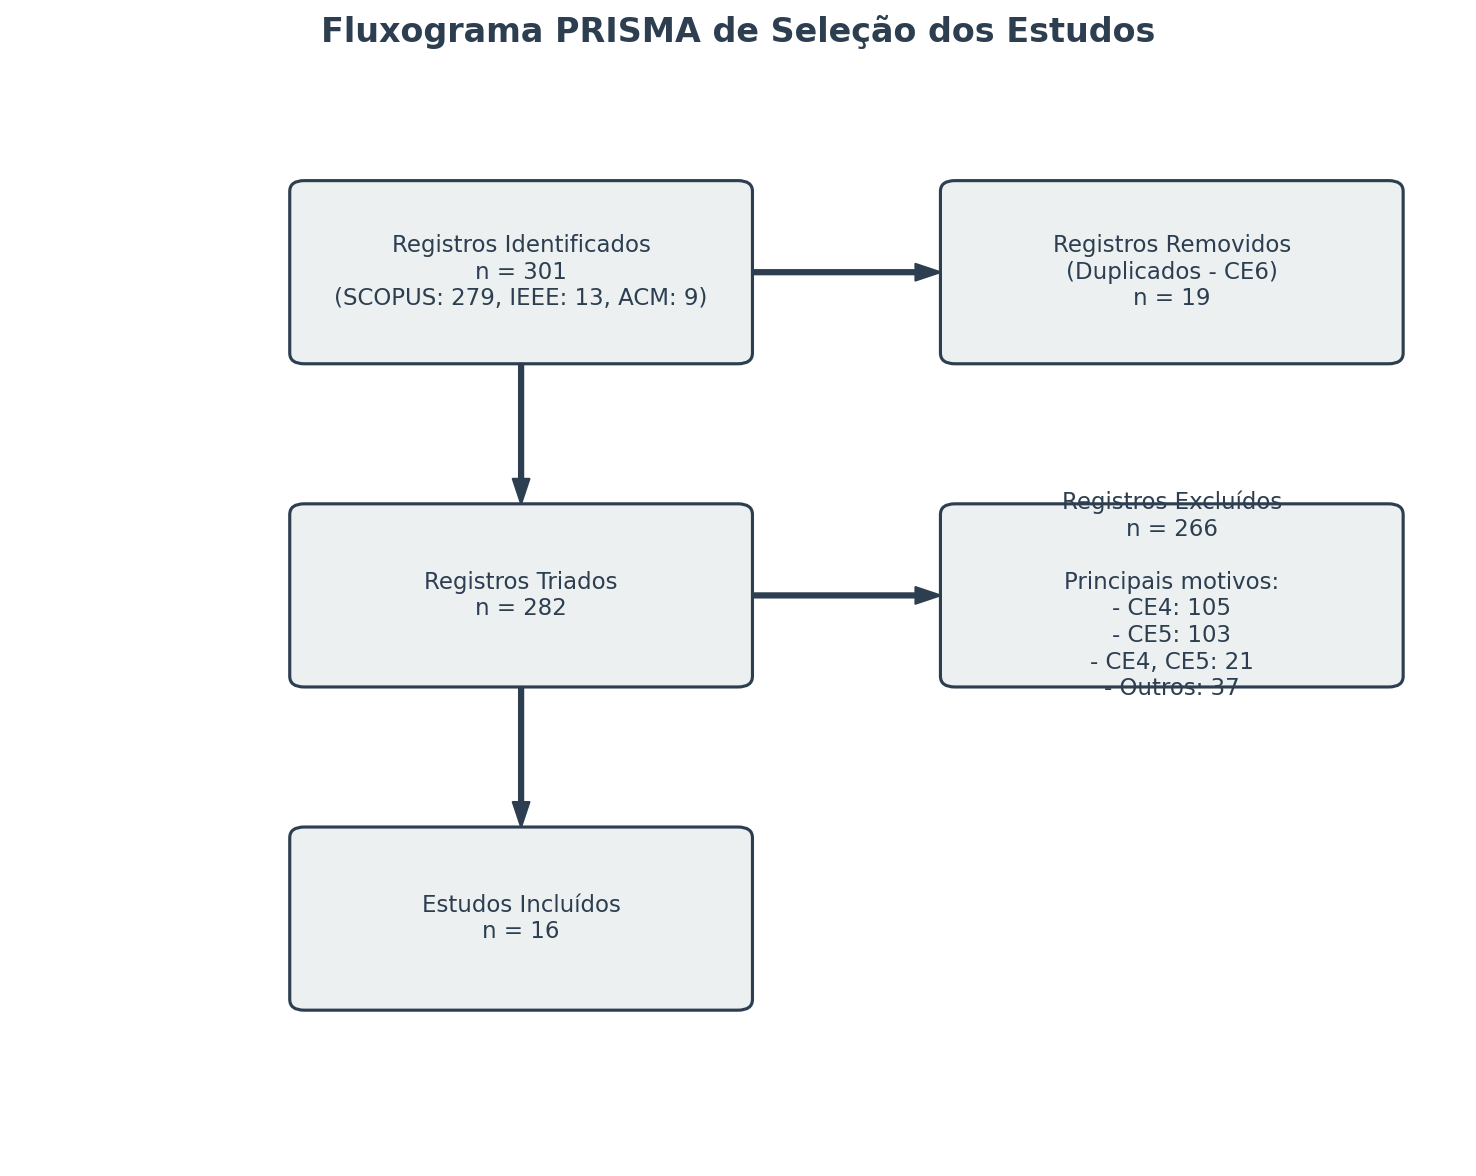

In [ ]:
# ==============================================================================
# TEXTOS DAS CAIXAS DO PRISMA
# ==============================================================================

texto_identificacao = f"Registros Identificados\nn = {total_identificados}\n({texto_bases})"
texto_duplicados = f"Registros Removidos\n(Duplicados - CE6)\nn = {duplicados}"
texto_triagem = f"Registros Triados\nn = {triados}"
texto_excluidos = f"Registros Excluídos\nn = {total_excluidos}\n\nPrincipais motivos:\n{str_motivos}\n- Outros: {outros_motivos}"
texto_incluidos = f"Estudos Incluídos\nn = {total_incluidos}"

# ==============================================================================
# CONSTRUÇÃO DO FLUXOGRAMA (MATPLOTLIB)
# ==============================================================================

fig, ax = plt.subplots(figsize=(10, 8))
ax.axis('off') # Esconde as linhas e eixos do gráfico

# Função para desenhar as caixas arredondadas
def draw_box(ax, x, y, width, height, text):
    box = patches.FancyBboxPatch((x, y), width, height, boxstyle="round,pad=1",
                                 edgecolor='#2c3e50', facecolor='#ecf0f1', lw=1.5)
    ax.add_patch(box)
    ax.text(x + width/2, y + height/2, text, ha='center', va='center', fontsize=11,
            color='#2c3e50', bbox=dict(facecolor='none', edgecolor='none'))

# Dimensões padrão das caixas
w, h = 30, 15

# Coordenadas (x, y) de cada caixa
b1_x, b1_y = 20, 75  # Caixa 1: Identificação
b2_x, b2_y = 65, 75  # Caixa 2: Duplicados (Lateral direita)
b3_x, b3_y = 20, 45  # Caixa 3: Triagem
b4_x, b4_y = 65, 45  # Caixa 4: Excluídos (Lateral direita)
b5_x, b5_y = 20, 15  # Caixa 5: Incluídos

# Desenhando as caixas
draw_box(ax, b1_x, b1_y, w, h, texto_identificacao)
draw_box(ax, b2_x, b2_y, w, h, texto_duplicados)
draw_box(ax, b3_x, b3_y, w, h, texto_triagem)
draw_box(ax, b4_x, b4_y, w, h, texto_excluidos)
draw_box(ax, b5_x, b5_y, w, h, texto_incluidos)

# Configurando o estilo das setas
arrow_props = dict(facecolor='#2c3e50', edgecolor='#2c3e50', width=2, headwidth=8, shrink=0)

# Seta 1: Identificação -> Triagem (Seta descendo)
ax.annotate('', xy=(b1_x + w/2, b3_y + h + 1), xytext=(b1_x + w/2, b1_y - 1), arrowprops=arrow_props)
# Seta 2: Identificação -> Duplicados (Seta para direita)
ax.annotate('', xy=(b2_x - 1, b1_y + h/2), xytext=(b1_x + w + 1, b1_y + h/2), arrowprops=arrow_props)

# Seta 3: Triagem -> Incluídos (Seta descendo)
ax.annotate('', xy=(b3_x + w/2, b5_y + h + 1), xytext=(b3_x + w/2, b3_y - 1), arrowprops=arrow_props)
# Seta 4: Triagem -> Excluídos (Seta para direita)
ax.annotate('', xy=(b4_x - 1, b3_y + h/2), xytext=(b3_x + w + 1, b3_y + h/2), arrowprops=arrow_props)

# Ajustes finais da área de renderização
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.title("Fluxograma PRISMA de Seleção dos Estudos", fontsize=16, fontweight='bold', pad=20, color='#2c3e50')
plt.tight_layout()

# Exibe o gráfico na tela do Colab e salva como imagem
plt.savefig('fluxograma_prisma.png', dpi=300, bbox_inches='tight')
plt.show()

# Síntese Bibliométrica (Tendência de Anos e Paradigmas)

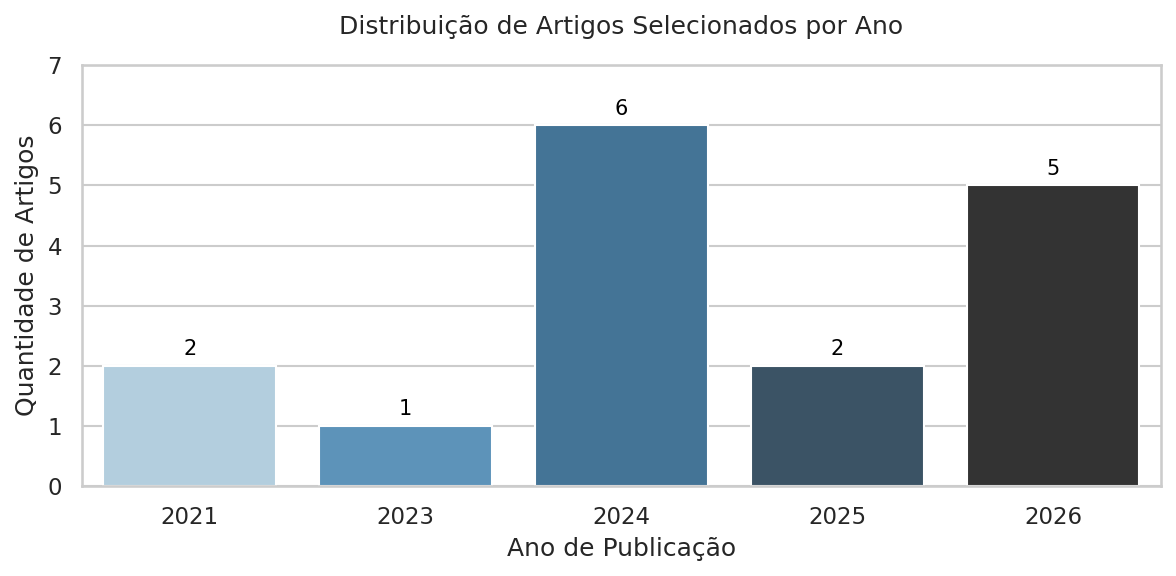

In [ ]:
# Gráfico 1: Distribuição por Ano
plt.figure(figsize=(8, 4))
ax = sns.countplot(data=df_extracao, x='Ano', hue='Ano', palette='Blues_d', legend=False)
plt.title('Distribuição de Artigos Selecionados por Ano', pad=15)
plt.ylabel('Quantidade de Artigos')
plt.xlabel('Ano de Publicação')

# Ajusta eixo Y para inteiros
ymax = df_extracao['Ano'].value_counts().max()
if pd.notna(ymax):
    plt.yticks(range(0, int(ymax) + 2))

# Adicionar os valores exatos em cima das barras
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.tight_layout()
plt.savefig('figura1_tendencia_anos.png', dpi=300)
plt.show()

# Gráfico 2: Frequência dos Paradigmas
# plt.figure(figsize=(10, 6))

# Como as descrições no seu arquivo são longas, vamos limitar o tamanho do texto no eixo Y
# df_extracao['Paradigma_Curto'] = df_extracao['Paradigma'].fillna('Não informado').apply(lambda x: x[:60] + '...' if len(x) > 60 else x)

# ordem_paradigmas = df_extracao['Paradigma_Curto'].value_counts().index
# x2 = sns.countplot(data=df_extracao, y='Paradigma_Curto', order=ordem_paradigmas, hue='Paradigma_Curto', palette='viridis', legend=False)
# plt.title('Frequência de Paradigmas de Linguagem Avaliados', pad=15)
# plt.xlabel('Quantidade de Artigos')
# plt.ylabel('Paradigma')
# plt.tight_layout()
# plt.savefig('figura2_paradigmas.png', dpi=300)
# plt.show()

# Gráfico de Barras Resumidas de Viés (Summary Bar Plot)

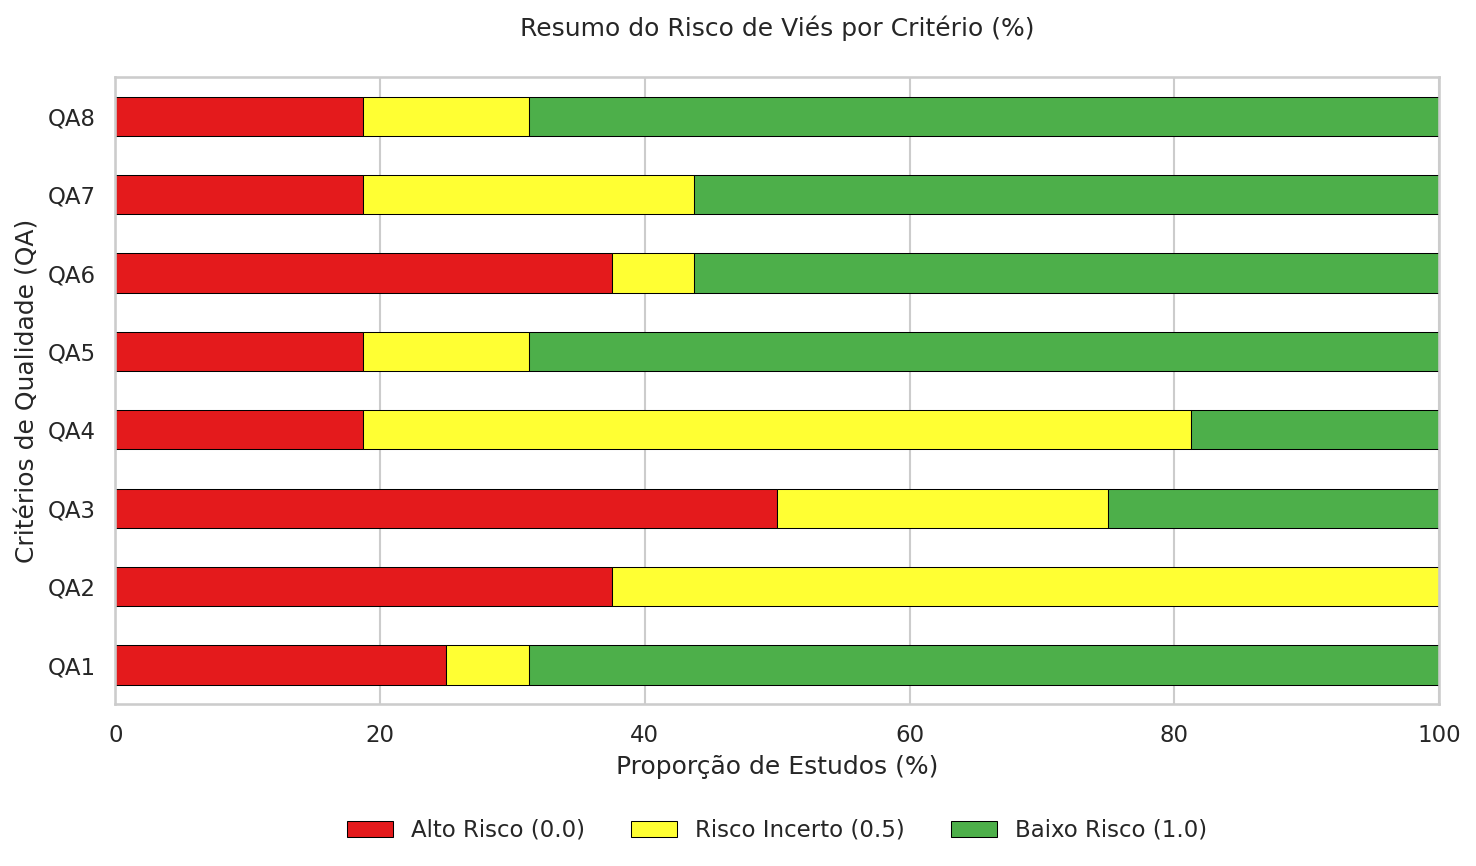

In [ ]:
# Preparar os dados de Qualidade
qa_data = df_qualidade[colunas_qa].copy()
# Renomear as colunas para exibir apenas "QA1", "QA2", etc. no gráfico
qa_data.columns = [col.split('_')[0] for col in qa_data.columns]

# Mapear os valores numéricos para categorias
mapa_qa = {1.0: 'Baixo Risco (1.0)', 0.5: 'Risco Incerto (0.5)', 0.0: 'Alto Risco (0.0)'}
qa_cat = qa_data.replace(mapa_qa)

# Calcular as proporções para cada critério
resumo_qa = qa_cat.apply(pd.Series.value_counts).fillna(0)
resumo_qa_pct = (resumo_qa / len(qa_cat)) * 100
resumo_qa_pct = resumo_qa_pct.T

# Garantir a ordem das colunas e das cores
for col in ['Baixo Risco (1.0)', 'Risco Incerto (0.5)', 'Alto Risco (0.0)']:
    if col not in resumo_qa_pct.columns:
        resumo_qa_pct[col] = 0

# Cores oficiais do semáforo: Vermelho, Amarelo, Verde
cores_bias_semaforo = ['#e41a1c', '#ffff33', '#4daf4a']

# Criar o gráfico de barras empilhadas 100%
fig, ax = plt.subplots(figsize=(10, 6))
resumo_qa_pct[['Alto Risco (0.0)', 'Risco Incerto (0.5)', 'Baixo Risco (1.0)']].plot(
    kind='barh', stacked=True, color=cores_bias_semaforo, ax=ax, edgecolor='black', linewidth=0.5
)

plt.title('Resumo do Risco de Viés por Critério (%)', pad=20)
plt.xlabel('Proporção de Estudos (%)')
plt.ylabel('Critérios de Qualidade (QA)')
plt.xlim(0, 100)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=False)

plt.tight_layout()
plt.savefig('figura3_qa_bar_plot.png', dpi=300)
plt.show()

# Gráfico de Semáforo (Traffic Light Plot)

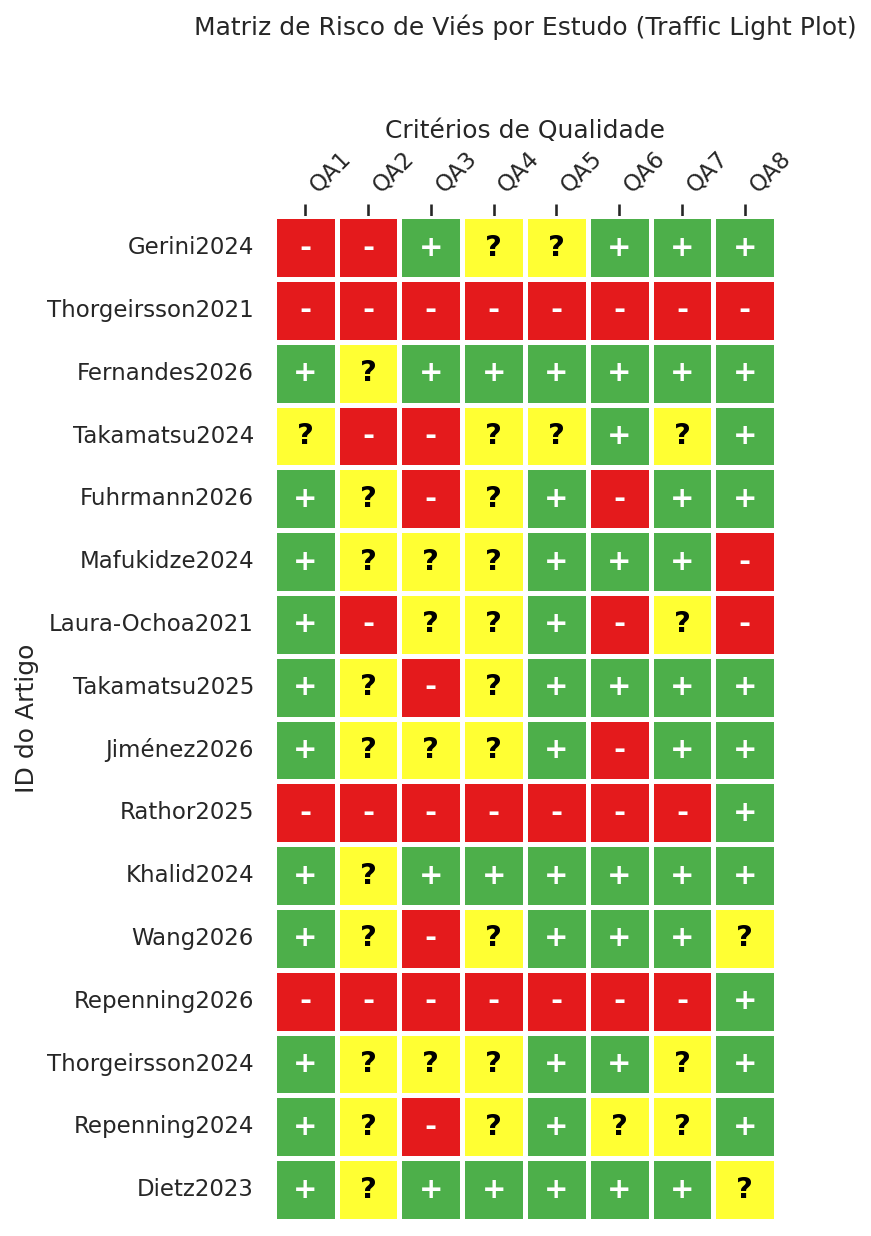

In [ ]:
# Preparar dados para o Heatmap
qa_data = df_qualidade[colunas_qa].copy()
qa_data.columns = [col.split('_')[0] for col in qa_data.columns]
qa_data.index = df_qualidade['ID_Artigo']

# Transformar as notas em 0, 1 e 2 para orientar o mapa de cores
mapa_heatmap = {0.0: 0, 0.5: 1, 1.0: 2}
qa_heatmap = qa_data.replace(mapa_heatmap)

# Mapa de cores discreto (Vermelho, Amarelo, Verde)
cmap_semaforo = mcolors.ListedColormap(['#e41a1c', '#ffff33', '#4daf4a'])
bounds = [-0.5, 0.5, 1.5, 2.5]
norm = mcolors.BoundaryNorm(bounds, cmap_semaforo.N)

# Ajuste automático da altura da figura com base nos seus 16 artigos
altura_fig = max(4, min(20, len(qa_data) * 0.4 + 2))
plt.figure(figsize=(10, altura_fig))
ax = sns.heatmap(qa_heatmap, cmap=cmap_semaforo, norm=norm,
                 linewidths=1.5, linecolor='white', cbar=False,
                 square=True, annot=False)

# Inserir símbolos (+, ?, -)
for i in range(qa_heatmap.shape[0]):
    for j in range(qa_heatmap.shape[1]):
        valor = qa_data.iloc[i, j]
        texto = "+" if valor == 1.0 else "?" if valor == 0.5 else "-"
        cor_texto = "white" if valor != 0.5 else "black"
        ax.text(j + 0.5, i + 0.5, texto, ha='center', va='center',
                color=cor_texto, fontsize=14, fontweight='bold')

# Estilizar visualmente
ax.xaxis.tick_top()
plt.xticks(rotation=45, ha='left')
plt.title('Matriz de Risco de Viés por Estudo (Traffic Light Plot)', pad=40)
plt.ylabel('ID do Artigo')
plt.xlabel('Critérios de Qualidade')
ax.xaxis.set_label_position('top')

plt.tight_layout()
plt.savefig('figura4_qa_traffic_light.png', dpi=300)
plt.show()